### **A3.1 PCA y Sistemas de Recomendación**


Bienvenidos al tutorial de PCA y Sistemas de Recomendación (esta parte sólo tendrá el código, debido a que se añade una "app" para hacer recomendaciones de películas).


Estará dividido en 2 secciones: PCA y Sistemas de Recomendación.


---
#### **PCA**


Para comenzar, cargaremos una base de datos ya incluida en la librería `sklearn` llamada `breast_cancer`. Para hacer esto, primero debemos de importar `load_breast_cancer` con la función `import` de las bases de datos de `sklearn.datasets`. Después, para poder manejar la base de datos se carga la librería `pandas`, al igual que la librería `matplotlib.pyplot` para poder poder crear ciertas gráficas.Además importaremos la librería `seaborn` para más adelante poder visualizar ciertos datos, como heatmaps.
Despúes, se convierte la información a tipo `DataFrame` para poder trabajarla mejor. Esto se hace con la función `DataFrame`, usando los datos de `breast_cancer.data` y añadiendo como columnas `breast_cancer.feature_names`, para poder conservar los valores de las variables. Por último agregamos un pequeño mensaje que indique que la base de datos se cargó correctamente, usando la función `print`



In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
breast_cancer = load_breast_cancer()

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df['target'] = breast_cancer.target

print("Dataset loaded successfully.")

Dataset loaded successfully.


Ahora, para conocer con qué tipo de datos estaremos trabajando imprimiremos las primeras 5 filas de los datos con la función `head()`. Después, para saber las dimensiones de la base, usamos la función `shape` e imprimimos con `print`. De igual manera, para conocer los tipos de datos de las variables y cuántos valores no nulos hay, usamos la función `info()` para después mostrarlos. Además, es importante que chequemos si hay valores faltantes, por lo que usaremos la función `isnull().sum()` para que sume todos los valores nulos que hay en la base de datos por columna. Además, imprimimos todos los nombres de las columnas con la función `print` y `.feature_names`. Además, imprimimos los nombres de la clase a predecir con `.target_names`. Por último, para conocer el balance entre clase imprimimos la distribución sumando los valores para cada clase objetivo e imprimiéndolas, con la función `.value_counts()` y `display`.











In [ ]:
# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Check the shape of the dataset
print(f"\nDataset shape: {df.shape}")

# Check data types and non-null values
print("\nData types and non-null values per column:")
display(df.info())

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# Display feature names
print("\nFeature names:")
print(breast_cancer.feature_names)

# Display target class names
print("\nTarget class names:")
print(breast_cancer.target_names)

# Display the distribution of the target variable
print("\nTarget variable distribution:")
display(df['target'].value_counts())

First 5 rows of the dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Dataset shape: (569, 31)

Data types and non-null values per column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error

None


Missing values per column:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0



Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target class names:
['malignant' 'benign']

Target variable distribution:


,count
target,
1,357
0,212


Como podrás observar, la base de datos tiene 569 observaciones y 31 variables. Además, todas las variables son numéricas; 30 tipo float64 y 1 tipo int64. De igual manera, podrás darte cuenta que no hay valores faltantes en ninguna columna. Puedes ver también todos los nombres de las variables, al igual que los tipos de clases (`malignant`, `benign`). Por último, hay 357 observaciones que pertenecen a la clase 1 y 212 que pertenecen a la clase 0; no parece haber un gran desbalance de clases.


Ahora que tenemos un mejor entendimiento de qué información hay en la base de datos podemos continuar con el siguiente paso.
Ahora, crearemos gráficas de densidad para todas las variables, para poder visualizar cómo se comportan las clases y si a simple vista parecen separables o no. Para esto, primero se guardan nombres de las variables en una nueva variable (excluyendo la variable de interés), así como se puede ver en la primera línea.  
Después puedes agregar unas líneas de código para acomodar de mejor manera las gráficas que se van a imprimir.


Ahora sí, para crear estas gráficas se usa un ciclo `for` para recorrer todas las variables y de todas crear una gráfica de densidad. La gráfica de densidad se crea usando la función `sns.kdeplot`, dándole como datos de entrada la base de datos(`data=df`), la columna a analizar (`x=feature`), que divida los datos según la columna objetivo (`hue = 'target'`), que las curvas creadas se rellene su área (`fill=True`) y que cada clase se normalice por separado, para que una gráfica no domine si es que tiene más datos(`common_norm=False`).


Luego puedes agregar algunas líneas extra para agregar título, leyendas y cambiar el tamaño de la letra, así como lo puedes ver en las últimas líneas de código.





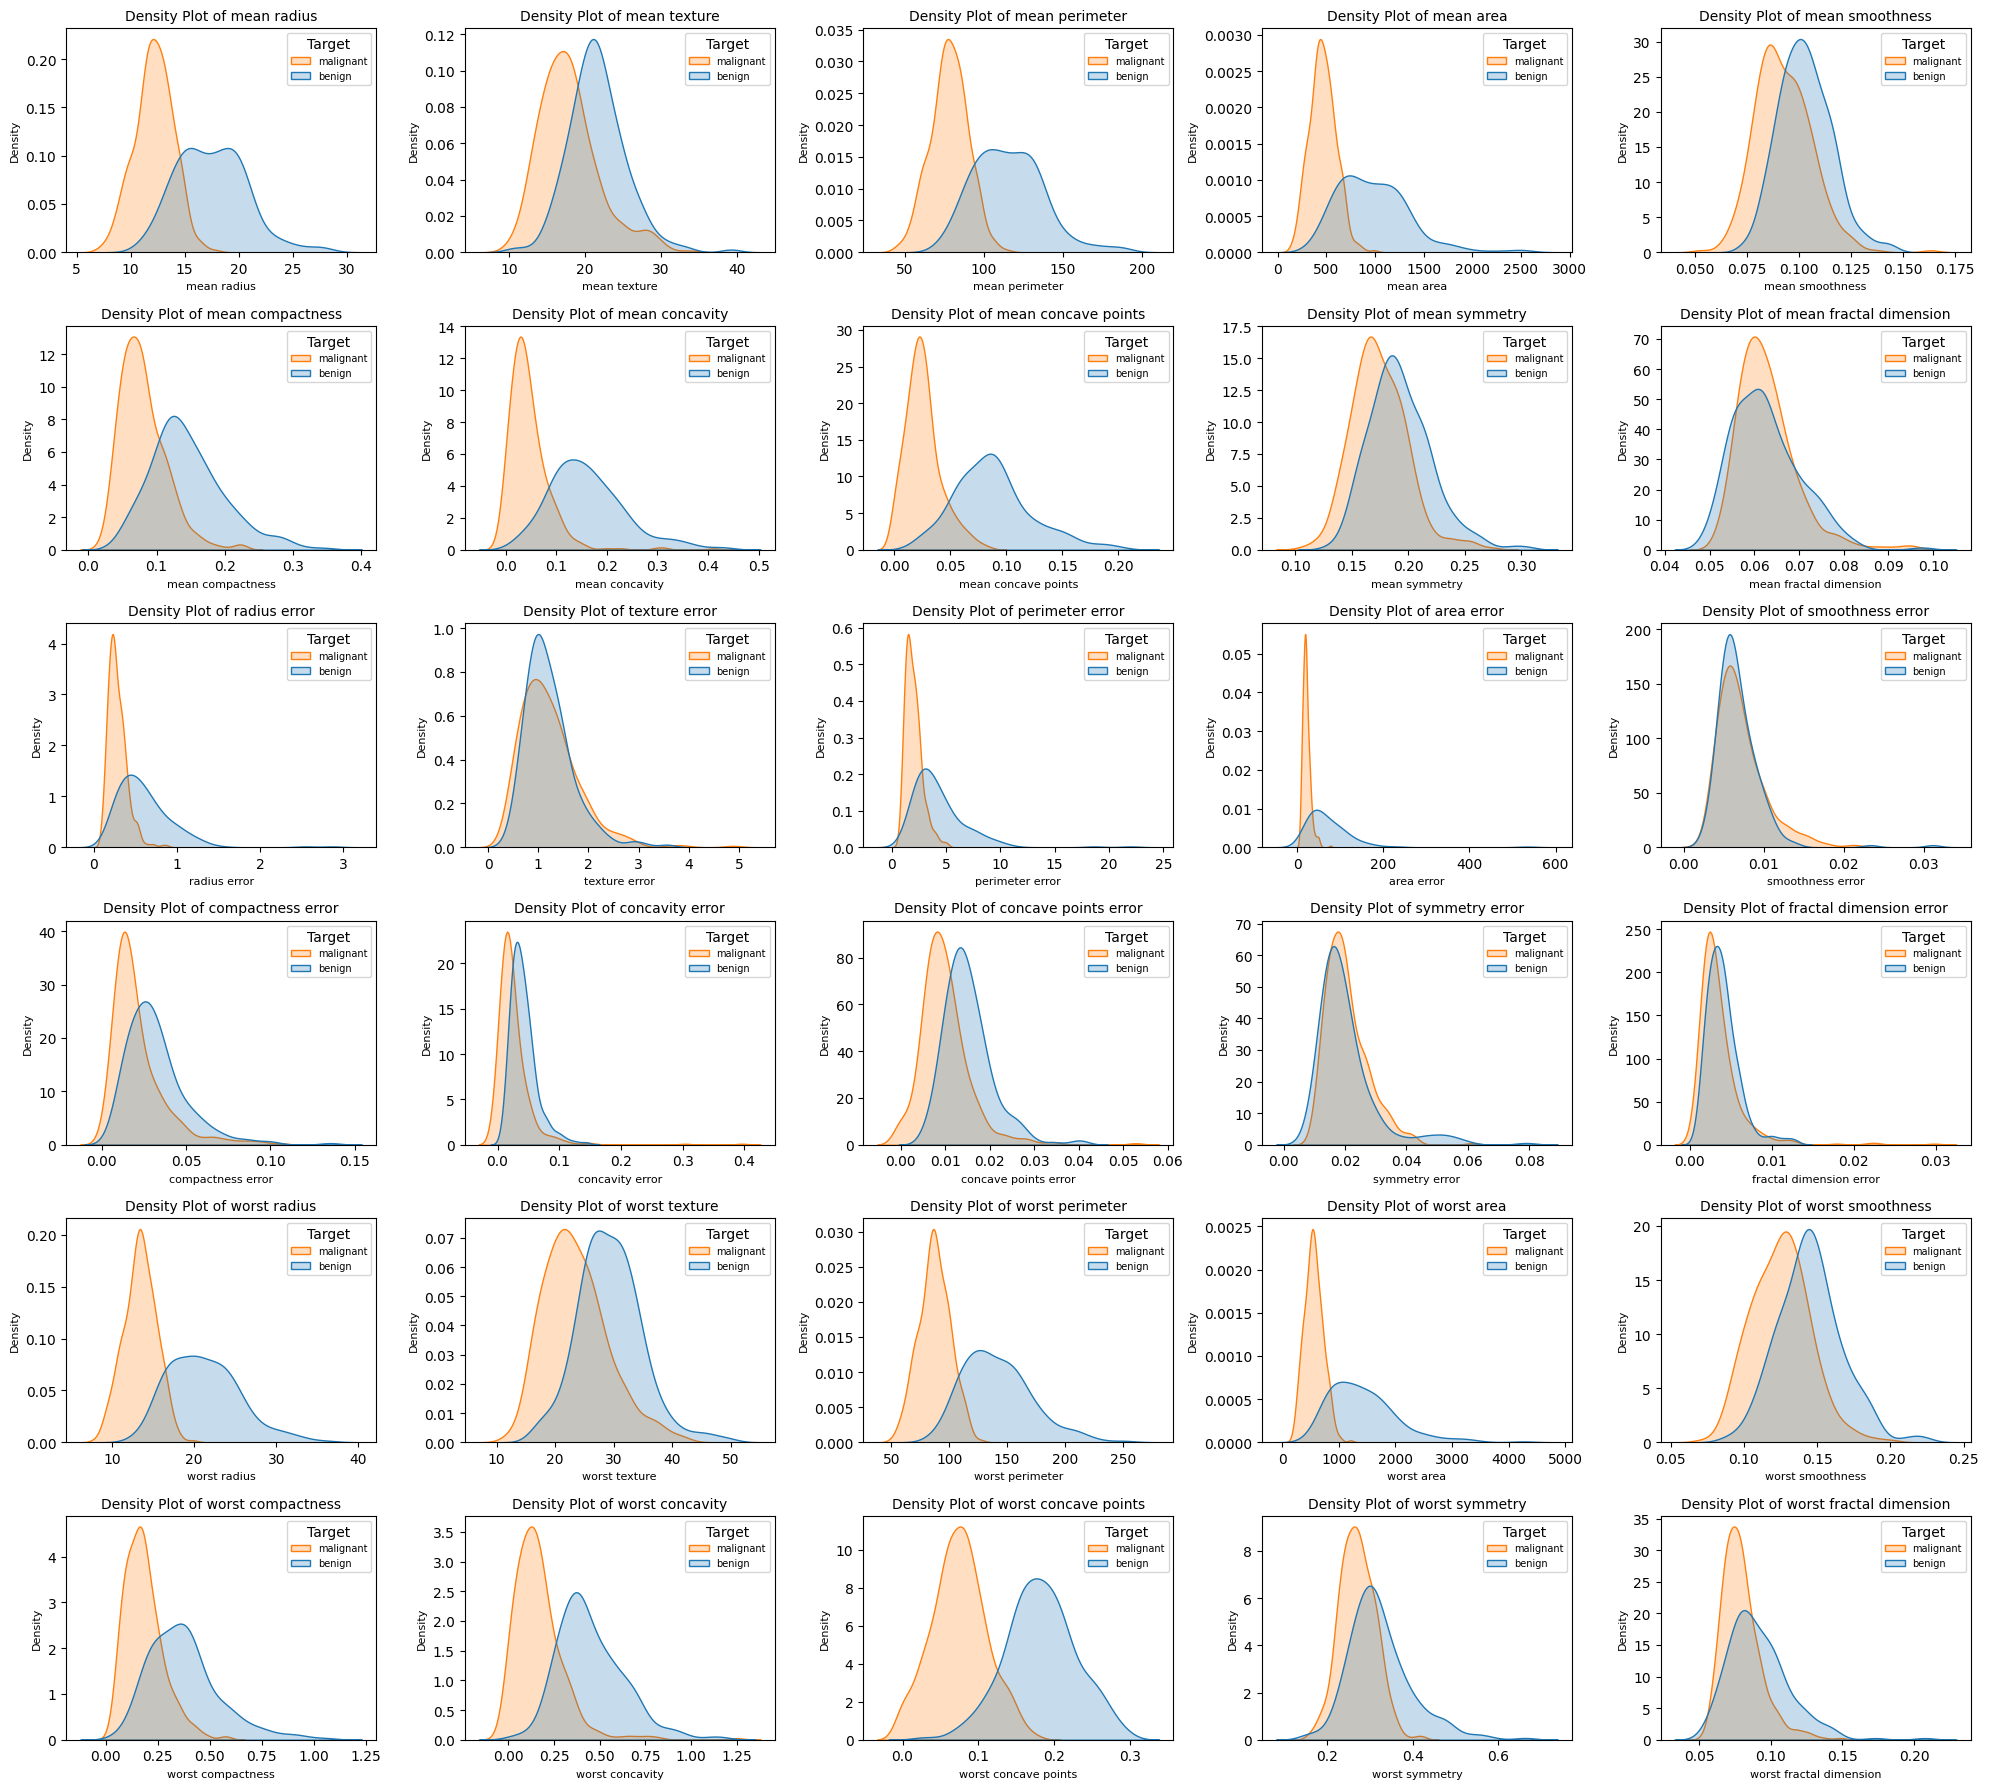

In [ ]:
# Get all feature names from the DataFrame, excluding the 'target' column
all_features = df.drop(columns=['target']).columns

# Calculate the number of rows and columns for the subplot grid
# Assuming 5 columns per row, adjust as needed
num_features = len(all_features)
num_cols = 5
num_rows = (num_features + num_cols - 1) // num_cols # Ceiling division

plt.figure(figsize=(num_cols * 4, num_rows * 3)) # Adjust figure size dynamically

for i, feature in enumerate(all_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.kdeplot(data=df, x=feature, hue='target', fill=True, common_norm=False)
    plt.title(f'Density Plot of {feature}', fontsize=10) # Smaller title font
    plt.xlabel(feature, fontsize=8) # Smaller label font
    plt.ylabel('Density', fontsize=8)
    plt.legend(title='Target', labels=breast_cancer.target_names, fontsize=7) # Smaller legend font
plt.tight_layout()
plt.show()

Como podrás ver, en múltiples de las gráficas de densidad hay un traslape significativo entre clases, lo que de inicio podría indicar que sería difícil distinguir entre clases. Eso lo comprobaremos más adelante, con la creación de un modelo de regresión logística.


Ahora, para ver cómo se comportan las clases comparando 2 variables y poder ver qué tanto se pueden separar las clases se crearán gráficas de dispersión sólo de 8 variables (4 gráficas en total, de 2 variables). Para esto se guardan todas las variables a usar en una variable, y luego se usa un `for` loop para pasar por todos los pares de variables y luego crear las gráficas con `sns.scatterplot`. Después puedes agregar unas líneas de código para añadir detalles a las gráficas, así como en las gráficas anteriores.


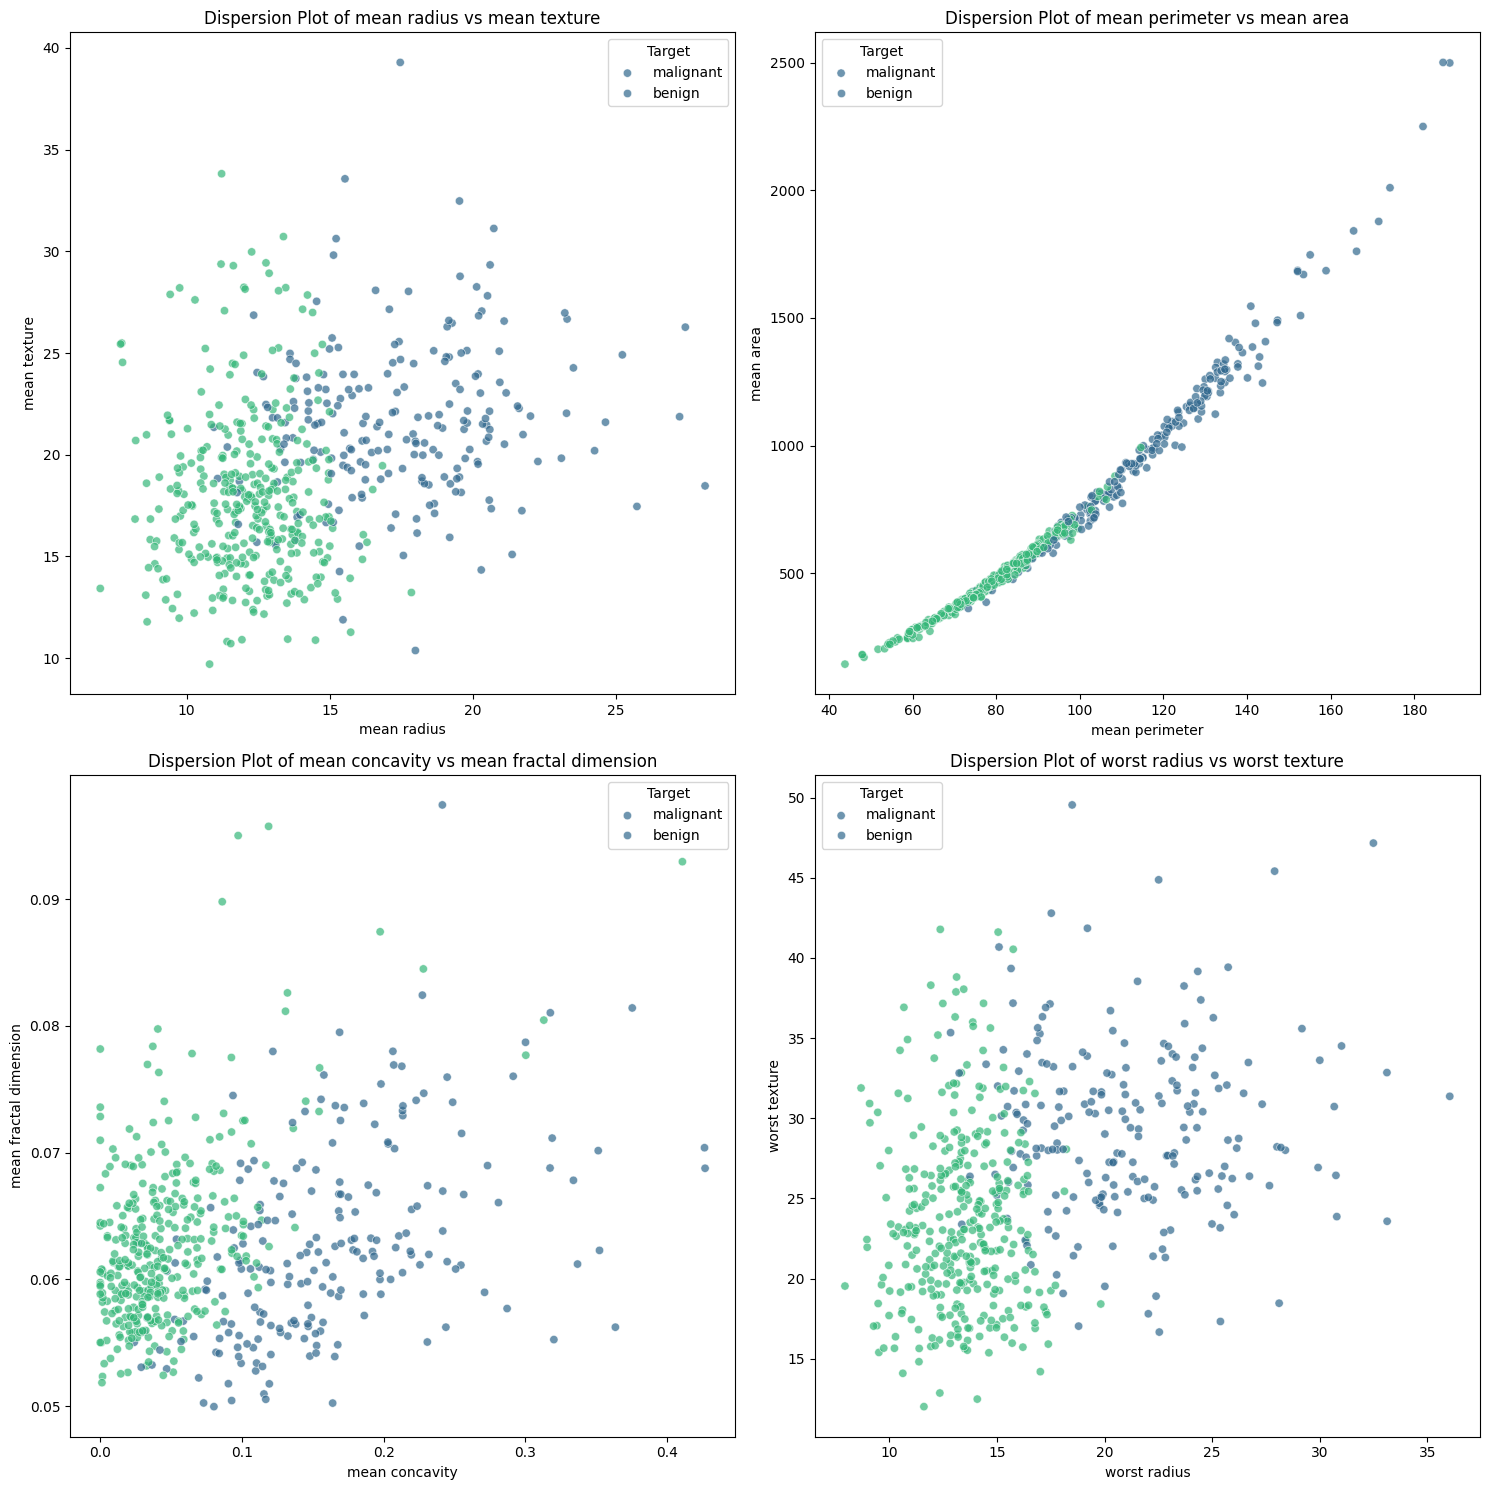

In [ ]:
# Select a few feature pairs for dispersion plots
selected_feature_pairs_scatter = [
    ('mean radius', 'mean texture'),
    ('mean perimeter', 'mean area'),
    ('mean concavity', 'mean fractal dimension'),
    ('worst radius', 'worst texture')
]

plt.figure(figsize=(15, 15))
for i, (feature_x, feature_y) in enumerate(selected_feature_pairs_scatter):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(data=df, x=feature_x, y=feature_y, hue='target', palette='viridis', alpha=0.7)
    plt.title(f'Dispersion Plot of {feature_x} vs {feature_y}')
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.legend(title='Target', labels=breast_cancer.target_names)
plt.tight_layout()
plt.show()

Como podrás ver, ninguna variable puede ser separada linealmente, aunque sí se pueden ver algunas tendencias en dónde se agrupan las distintas clases.


Ahora, haremos la separación en train y test, 70 - 30. Para esto, importamos la librería `train_test_split` y de ahí usaremos la función `train_test_split`, para la variable `X` y `y`, usando `y=stratify` para mantener la proporción de clases y que no el modelo no aprenda sólo con una clase. Además, para reproducibilidad, añadí una semilla de aleatoriedad de 1. Pero la puedes cambiar, sólo ten en cuenta que obtendrás resultados distintos a los míos. Imprimimos los tamaños de los nuevos conjuntos.


Después de hacer eso, estandarizaremos los datos, para que los datos con valores más altos no predomine más en el modelo. Para esto, necesitamos hacer que la media para cada variable de `X` sea 0 y la desviación estándar sea 1. Esto lo logramos con la función `StandarScaler()`, de la librería `StandarScaler`. Recordemos que debemos ajustar la estandarización sólo con los datos de entrenamiento (con `fit_transform`), para que no haya fuga de datos. Y con estos, después se transforman los datos de prueba (sólo con la función `transform`).


Para confirmar que se haya realizado correctamente, se imprimen las primeras filas de ambos conjuntos, con `display` y `head()` para mostrar las primeras 5 filas.







In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets (70% train, 30% test)
# Use stratify=y to ensure the same proportion of target classes in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames (optional, but good for inspection)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Data standardization complete.")
print("First 5 rows of X_train_scaled:")
display(X_train_scaled.head())
print("First 5 rows of X_test_scaled:")
display(X_test_scaled.head())

X_train shape: (398, 30)
X_test shape: (171, 30)
y_train shape: (398,)
y_test shape: (171,)
Data standardization complete.
First 5 rows of X_train_scaled:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
227,0.264490,-0.886007,0.238466,0.098019,-0.953518,0.080407,-0.307205,-0.290733,0.222223,-0.569352,...,0.036080,-1.055611,0.207941,-0.121227,-0.854385,0.642597,0.276551,0.319875,0.046004,-0.062579
104,-1.011239,-0.018809,-0.986729,-0.879673,0.217189,-0.364336,-0.733052,-0.943864,1.461537,0.250992,...,-0.962862,-0.409558,-0.963623,-0.817326,-0.486800,-0.680521,-0.923365,-1.255806,-0.156854,-0.513764
248,-0.965981,1.341637,-0.962258,-0.849085,-0.023030,-0.615273,-0.807788,-0.839019,0.281238,0.033758,...,-0.817226,1.509220,-0.853441,-0.726493,0.753243,-0.734904,-0.772966,-0.819282,0.767102,-0.182338
356,-0.287100,-0.179401,-0.265642,-0.386057,0.818461,0.468763,0.068657,0.170941,0.790242,0.279575,...,-0.419290,-0.160827,-0.377548,-0.493830,0.062362,0.043764,-0.105553,0.139788,0.297992,-0.087645
90,0.157000,1.066336,0.121004,0.036843,-0.517216,-0.359108,-0.720070,-0.499158,-0.500709,-0.627948,...,-0.025456,0.527219,-0.123191,-0.128953,-0.947388,-0.507483,-0.867962,-0.698729,-0.638643,-0.684212


First 5 rows of X_test_scaled:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
256,1.551533,2.156069,1.712860,1.564276,-0.310280,1.885888,1.068003,1.649160,0.266485,-0.104872,...,1.808332,1.683654,2.095102,1.798111,-0.212219,1.694417,0.667873,1.156308,-0.169533,0.877668
560,-0.004234,1.784413,-0.009102,-0.137986,0.173776,0.136419,-0.555070,-0.158030,-1.046598,-0.192051,...,-0.191605,1.182963,-0.202311,-0.295509,-0.389368,-0.199724,-0.680321,-0.172758,-1.069717,-0.085417
299,-1.005582,0.852978,-1.009569,-0.885005,0.333681,-0.696865,-0.793714,-0.773174,-0.463825,0.358179,...,-1.087987,-0.262581,-1.084354,-0.886180,-0.823384,-1.066518,-1.099851,-1.267414,-1.106168,-0.945453
343,1.588306,0.529499,1.561953,1.527795,0.078267,0.534111,1.163849,1.545327,0.963599,-0.843752,...,1.336552,1.423618,1.479724,1.135323,-0.491229,0.538157,0.890497,1.623639,1.775055,-0.309895
131,0.394608,0.024781,0.411804,0.278740,0.890816,0.317528,0.682193,0.800013,0.406645,-0.727989,...,0.620677,0.024913,0.521491,0.475969,0.961393,-0.119385,0.455849,0.520797,-0.139421,-0.253636


Ahora, tenemos 398 datos de entrenamiento y 171 datos para prueba. También podemos ver que ahora las observaciones no varían mucho en rango, por lo que podemos confirmar que se realizó correctamente la estandarización.


Ahora, realizaremos un modelo de regresión logística, donde la optimización de parámetros será bastante sencilla, usando `GridSearch`. El parámetro que se optimiza es el `C`, que es la regularización inversa. También se optimiza la penalidad. Inicializamos el modelo con `LogisticResession` de la librería con el mismo nombre. Añadimos el solver `liblinear` y el random state igual a uno.


Luego, se hace la búsqueda de los mejores parámetros, eligiendo el mejor modelo en base al mejor `f1 score`. Después, para saber cuáles fueron los mejores parámetros para entrenar el modelo, los imprimimos, en conjunto con el mejor F1 score obtenido. Para poder calcular las métricas del modelo también debemos importar las librerías `accuracy_score`, `f1_score`, `roc_auc_score`, `confusion_matrix`, `classification_report`.







In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:

# Initialize Logistic Regression model
log_reg = LogisticRegression(solver='liblinear', random_state=1)

# Define parameter grid for GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Initialize GridSearchCV with f1-score as the scoring metric
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV on the scaled training data
grid_search.fit(X_train_scaled, y_train)

print("Grid search complete.")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1 score: {grid_search.best_score_:.4f}")

# Get the best model
best_log_reg_model = grid_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid search complete.
Best parameters: {'C': 0.1, 'penalty': 'l2'}
Best F1 score: 0.9863


Podemos ver que los mejores parámetros encontrados son:
`C = 0.1` y `penalty = l2`. El mejor F1 score que se encontró fue `0.9863`.


Ahora, con este modelo, vamos a ponerlo a prueba en el conjunto de datos de entrenamiento y en los datos de prueba. Para esto, se hacen predicciones con los datos de `X` para `y` y luego se comparan con los valores reales de `y`. Esto lo hacemos con ambos conjuntos. Usamos la función `predict` para predecir y `accuracy_score`, `f1_score` y `roc_auc_score` para calcular las métricas.


Después los imprimimos para poderlos comparar.

In [ ]:
# --- Evaluate on Training Data ---
print("\n--- Evaluation on Training Data ---")
y_train_pred = best_log_reg_model.predict(X_train_scaled)
y_train_prob = best_log_reg_model.predict_proba(X_train_scaled)[:, 1]

train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

print(f"Accuracy (Train): {train_accuracy:.4f}")
print(f"F1 Score (Train): {train_f1:.4f}")
print(f"AUC (Train): {train_auc:.4f}")
print("Classification Report (Train):\n", classification_report(y_train, y_train_pred))

# --- Evaluate on Test Data ---
print("\n--- Evaluation on Test Data ---")
y_test_pred = best_log_reg_model.predict(X_test_scaled)
y_test_prob = best_log_reg_model.predict_proba(X_test_scaled)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print(f"Accuracy (Test): {test_accuracy:.4f}")
print(f"F1 Score (Test): {test_f1:.4f}")
print(f"AUC (Test): {test_auc:.4f}")
print("Classification Report (Test):\n", classification_report(y_test, y_test_pred))


--- Evaluation on Training Data ---
Accuracy (Train): 0.9874
F1 Score (Train): 0.9901
AUC (Train): 0.9959
Classification Report (Train):
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       148
           1       0.98      1.00      0.99       250

    accuracy                           0.99       398
   macro avg       0.99      0.98      0.99       398
weighted avg       0.99      0.99      0.99       398


--- Evaluation on Test Data ---
Accuracy (Test): 0.9532
F1 Score (Test): 0.9636
AUC (Test): 0.9958
Classification Report (Test):
               precision    recall  f1-score   support

           0       0.98      0.89      0.93        64
           1       0.94      0.99      0.96       107

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



Si usaste la misma semilla de aleatoriedad que yo, podrás ver que obtuvimos un accuracy en train de 0.9874 y un accuracy en test de 0.9532. También, tenemos un F1 score en entrenamiento de 0.9901 y en prueba de 0.9636. Estos valores indican que el modelo sí parece ser bueno distingiendo entre clases, sin cometer muchos errores clasificando.


Ahora, aplicaremos PCA a los datos.
El Principal Component Analysis es una técnica que se usa para reducir la cantidad de variables manteniendo la mayor cantidad posible de información importante. En este caso, tenemos 30 variables. Aplicaremos esto y veremos qué tantas variables se pueden eliminar sin que se pierda información relevante de la base de datos.  
Con este método se crea un nuevo conjunto de variables llamadas "componentes principales", que son una combinación de las variables originales, las cuales están ordenadas por importancia (primero van las que más variabilidad expliquen) y son independientes entre sí.




Para esto vamos a comenzar importante la libería `PCA`. Incializamos el PCA, dejando todos los componentes para analizar la variabilidad que explican todos. Ahora, ajustamos PCA usando los datos escalados de entrenamiento, para posteriormente transformar tanto los datos de entrenamiento como los datos de prueba al nuevo espacio de componentes principales. Luego imprimimos la cantidad de variables de la base de datos original y la cantidad de componentes después de aplicar PCA (que debe ser la misma cantidad porque anteriormente establecimos que íbamos a conservar todos los componentes al poner `n_components=None`.


Ahora, para ver qué tantos componentes explican gran parte de la información vamos a imprimir el "explained variance ratio" que es cuánta información de los datos originales explica cada componte principal. Esto lo hacemos con la función `explained_variance_ratio_` y creamos un `for` loop para imprimir este datos para todos los componentes que tenemos.









In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA - choose a number of components, or leave none to keep all components
pca = PCA(n_components=None) # Keep all components for now to analyze explained variance

# Fit PCA on the scaled training data
pca.fit(X_train_scaled)

# Transform both training and test data
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA applied successfully.")
print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of components after PCA: {X_train_pca.shape[1]}")

# Display the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("\nExplained variance ratio per component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f}")

PCA applied successfully.
Original number of features: 30
Number of components after PCA: 30

Explained variance ratio per component:
Principal Component 1: 0.4471
Principal Component 2: 0.1901
Principal Component 3: 0.0904
Principal Component 4: 0.0685
Principal Component 5: 0.0510
Principal Component 6: 0.0431
Principal Component 7: 0.0236
Principal Component 8: 0.0152
Principal Component 9: 0.0138
Principal Component 10: 0.0110
Principal Component 11: 0.0095
Principal Component 12: 0.0090
Principal Component 13: 0.0075
Principal Component 14: 0.0047
Principal Component 15: 0.0030
Principal Component 16: 0.0023
Principal Component 17: 0.0020
Principal Component 18: 0.0017
Principal Component 19: 0.0016
Principal Component 20: 0.0010
Principal Component 21: 0.0009
Principal Component 22: 0.0008
Principal Component 23: 0.0007
Principal Component 24: 0.0005
Principal Component 25: 0.0005
Principal Component 26: 0.0003
Principal Component 27: 0.0002
Principal Component 28: 0.0000
Princip

Como podemos ver, los primeros componentes explican más varianza que los últimos componentes. De esta manera, conservando sólo algunos componentes podemos explicar gran parte de la información de la base de datos original.

Después de haber realizado esto, haremos 2 heatmaps que comparen la estructura de los datos antes y después de aplicar PCA. Estaremos comparando las Observaciones contra las Variables y luego contra los Componentes. Usaremos la función `sns.heatmap` con los datos de `X_train_scales` y `X_train_pca`.

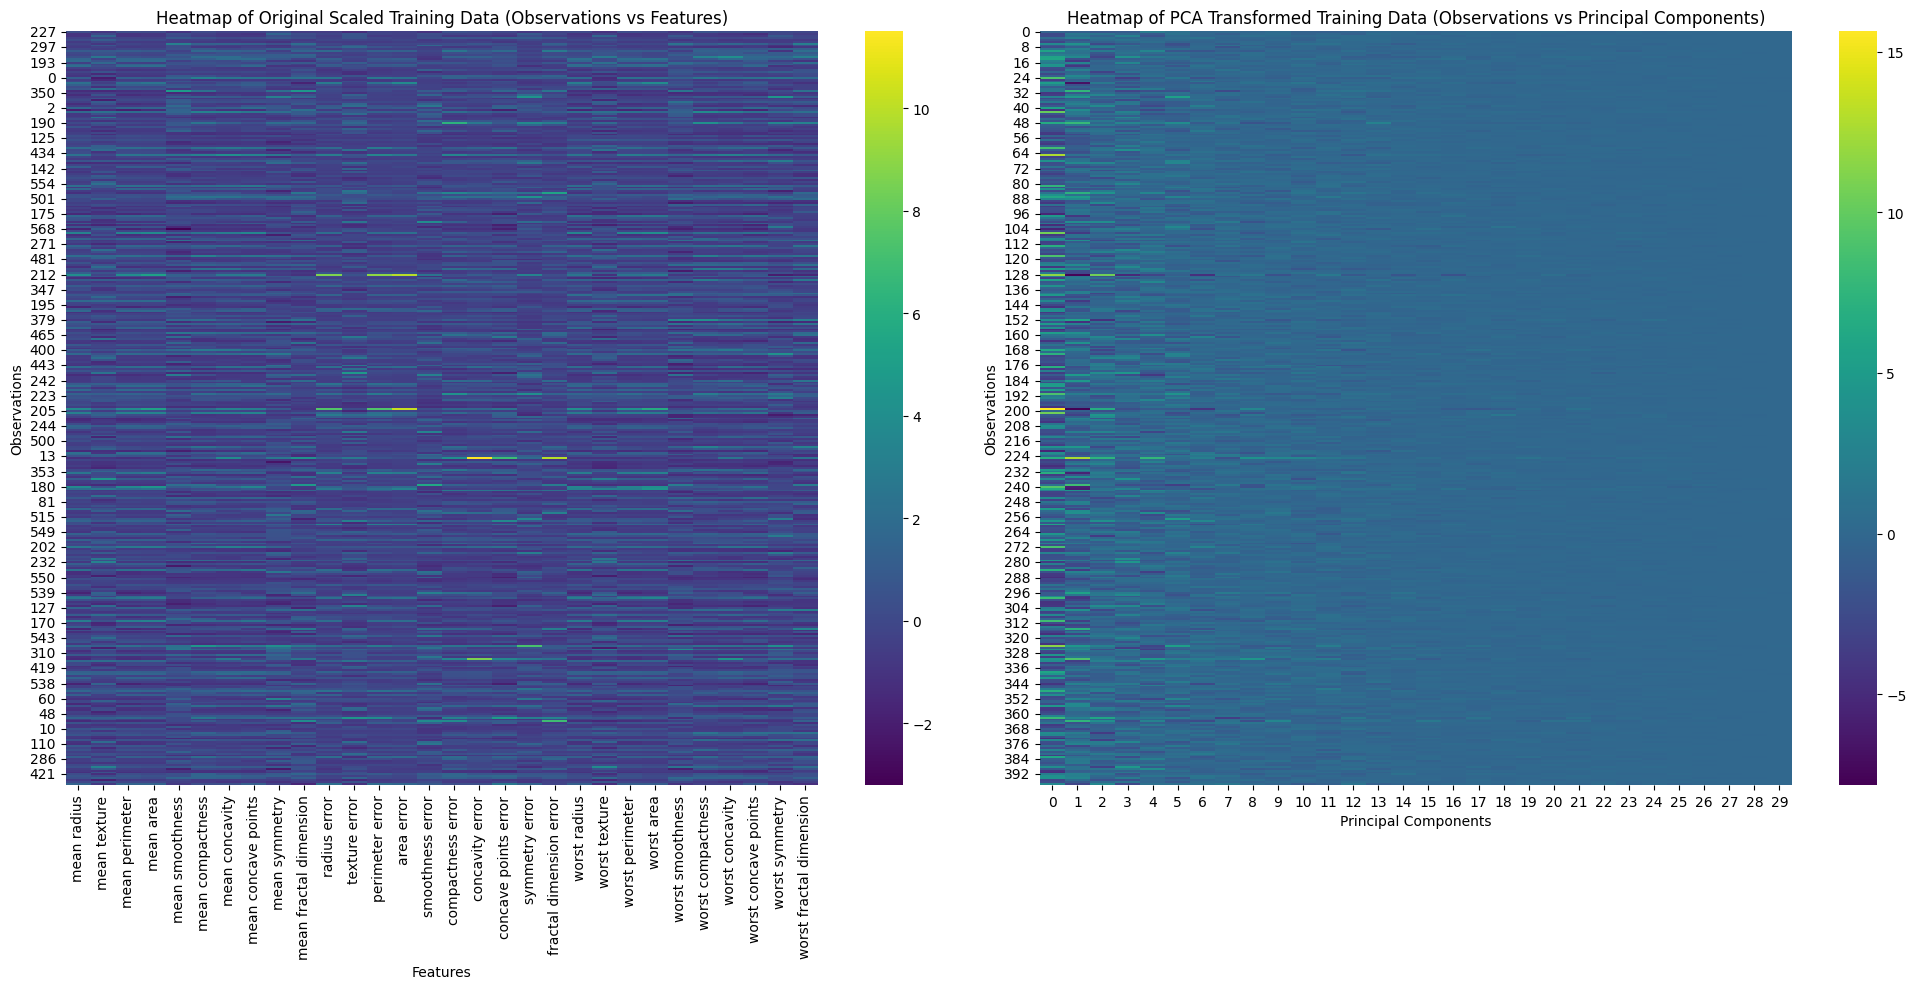

In [ ]:
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
sns.heatmap(X_train_scaled, cmap='viridis')
plt.title('Heatmap of Original Scaled Training Data (Observations vs Features)')
plt.xlabel('Features')
plt.ylabel('Observations')

plt.subplot(1, 2, 2)
sns.heatmap(pd.DataFrame(X_train_pca), cmap='viridis')
plt.title('Heatmap of PCA Transformed Training Data (Observations vs Principal Components)')
plt.xlabel('Principal Components')
plt.ylabel('Observations')

plt.tight_layout()
plt.show()

Como podemos ver, en el segundo gráfico conforme van ascendiendo los componentes, el color de las celdas comienza a hacerse del mismo, indicando lo mismo que comprobamos hace rato: los primeros componentes explican la mayor varianza de los datos a diferencia de los últimos componentes.


A continuación, haremos 2 heatmaps para evaluar la correlación entre las variables de la base de datos original y haremos otro para ver la correlación entre los componentes después del PCA. Como mencioné anteriormente, los componentes deben ser independientes unos de otros, por lo que en el segundo heatmap deberíamos no ver ninguna correlación entre los componentes.


Usaremos la misma función para crear el heatmap que en el paso pasado pero agregaremos la función `.corr()` para crear la matriz de correlación.







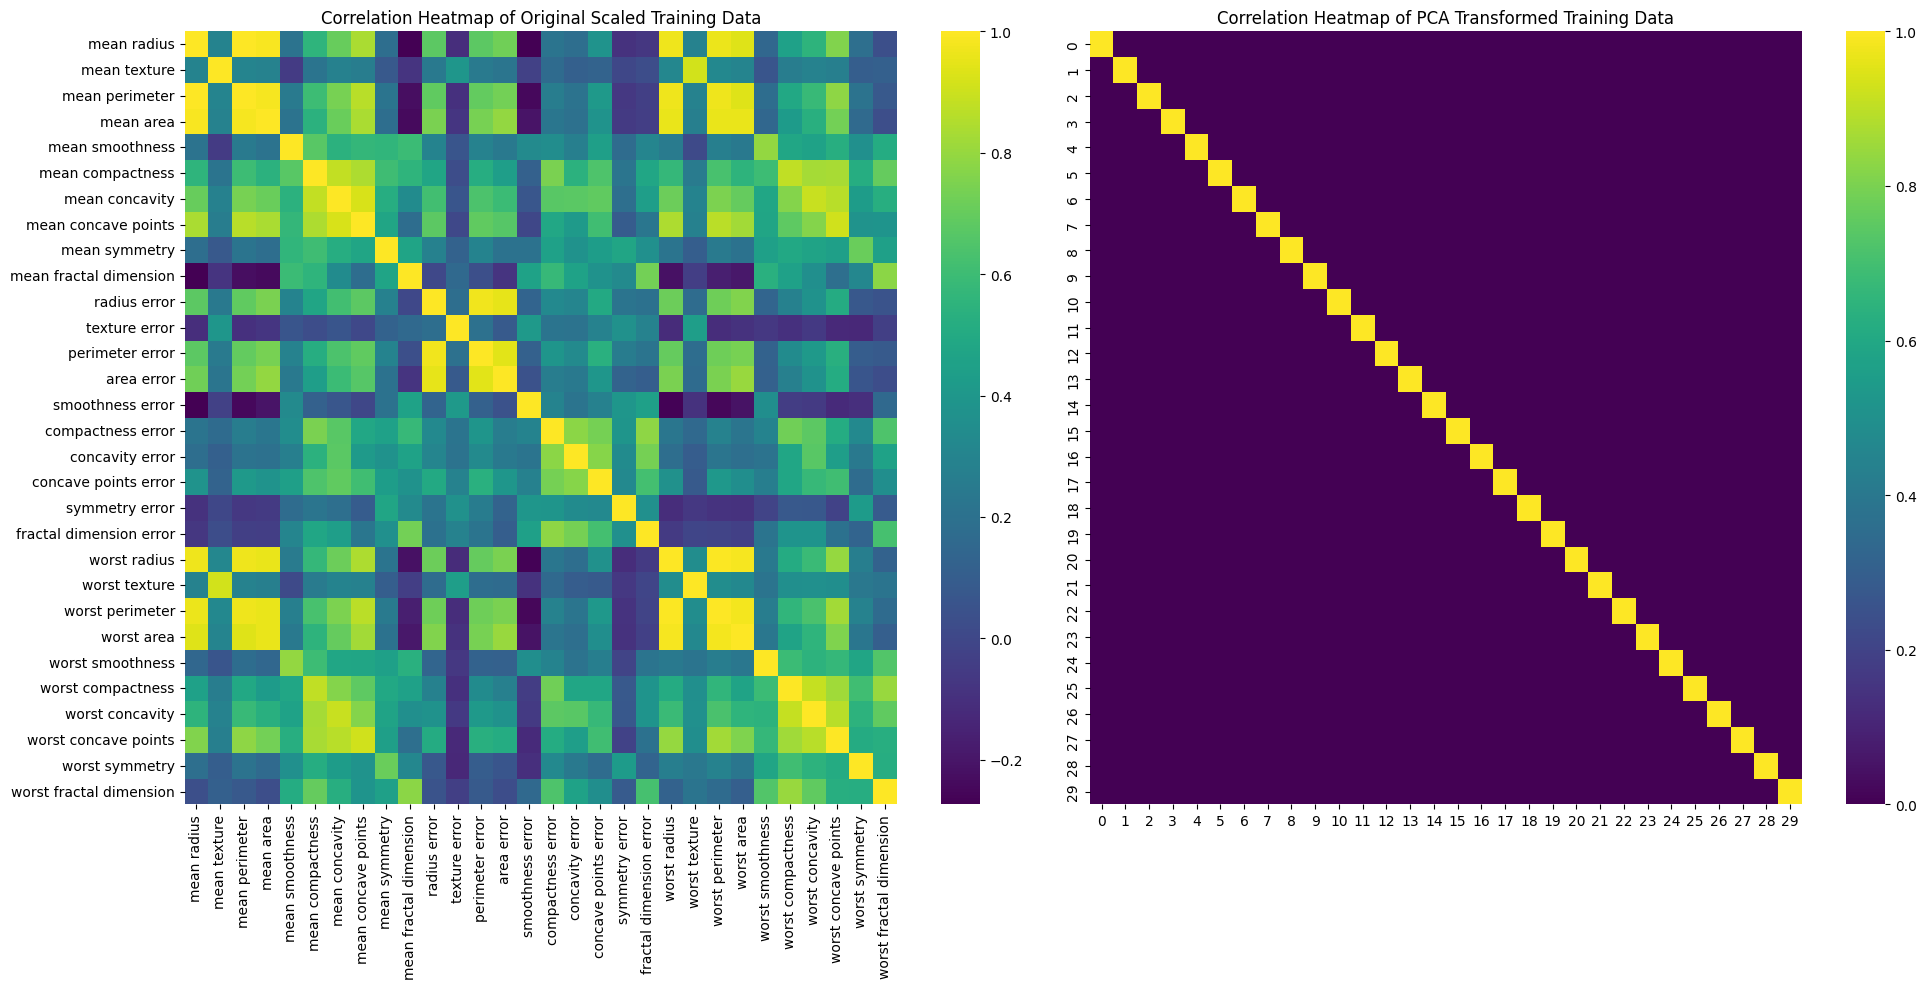

In [ ]:
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
sns.heatmap(X_train_scaled.corr(), cmap='viridis', annot=False)
plt.title('Correlation Heatmap of Original Scaled Training Data')

plt.subplot(1, 2, 2)
sns.heatmap(pd.DataFrame(X_train_pca).corr(), cmap='viridis', annot=False)
plt.title('Correlation Heatmap of PCA Transformed Training Data')

plt.tight_layout()
plt.show()

Como comenté, podemos ver que sí se cumple que hay correlación de 0 entre todos los componentes de los datos después de PCA, debido a esta independencia que deben tener unos por otros. Podemos ver que también hacemos Por el contrario, podrás ver que en la matriz de la izquierda sí hay variables que tienen correlaciones altas con otras variables.
Hacer estos heatmaps ayuda a confirmar que PCA hizo un buen trabajo eliminando redundancia y haciendo sus componentes independientes.


Ya que hicimos esto, entrenaremos un modelo de regresión logística con los datos de PCA. Usaremos el mismo procedimiento que en la creación del modelo anterior, optimizando los mismo parámetros que en los pasos pasados, para ver el desempeño del modelo después de usar este método.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

# Initialize Logistic Regression model
log_reg_pca = LogisticRegression(solver='liblinear', random_state=1)

# Define parameter grid for GridSearchCV
param_grid_pca = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Initialize GridSearchCV with f1-score as the scoring metric
grid_search_pca = GridSearchCV(log_reg_pca, param_grid_pca, cv=5, scoring='f1', n_jobs=-1, verbose=1)

# Fit GridSearchCV on the PCA-transformed training data
grid_search_pca.fit(X_train_pca, y_train)

print("Grid search with PCA data complete.")
print(f"Best parameters (PCA): {grid_search_pca.best_params_}")
print(f"Best F1 score (PCA): {grid_search_pca.best_score_:.4f}")

# Get the best model for PCA data
best_log_reg_model_pca = grid_search_pca.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid search with PCA data complete.
Best parameters (PCA): {'C': 0.1, 'penalty': 'l2'}
Best F1 score (PCA): 0.9863


Encontramos que los mejores parámetros son `C = 0.1` y `penalty = l2`, con un el mejor F1 score de `0.9863`.


Evaluaremos el modelo nuevo en los datos de prueba y entrenamiento, para después compararlo con el modelo anterior. De igual manera, usaremos el mismo procedimiento que en el modelo anterior.


In [ ]:
# --- Evaluate on Training Data with PCA ----
print("\n--- Evaluation on Training Data (PCA) ---")
y_train_pred_pca = best_log_reg_model_pca.predict(X_train_pca)
y_train_prob_pca = best_log_reg_model_pca.predict_proba(X_train_pca)[:, 1]

train_accuracy_pca = accuracy_score(y_train, y_train_pred_pca)
train_f1_pca = f1_score(y_train, y_train_pred_pca)
train_auc_pca = roc_auc_score(y_train, y_train_prob_pca)

print(f"Accuracy (Train PCA): {train_accuracy_pca:.4f}")
print(f"F1 Score (Train PCA): {train_f1_pca:.4f}")
print(f"AUC (Train PCA): {train_auc_pca:.4f}")
print("Classification Report (Train PCA):\n", classification_report(y_train, y_train_pred_pca))

# --- Evaluate on Test Data with PCA ----
print("\n--- Evaluation on Test Data (PCA) ---")
y_test_pred_pca = best_log_reg_model_pca.predict(X_test_pca)
y_test_prob_pca = best_log_reg_model_pca.predict_proba(X_test_pca)[:, 1]

test_accuracy_pca = accuracy_score(y_test, y_test_pred_pca)
test_f1_pca = f1_score(y_test, y_test_pred_pca)
test_auc_pca = roc_auc_score(y_test, y_test_prob_pca)

print(f"Accuracy (Test PCA): {test_accuracy_pca:.4f}")
print(f"F1 Score (Test PCA): {test_f1_pca:.4f}")
print(f"AUC (Test PCA): {test_auc_pca:.4f}")
print("Classification Report (Test PCA):\n", classification_report(y_test, y_test_pred_pca))


--- Evaluation on Training Data (PCA) ---
Accuracy (Train PCA): 0.9874
F1 Score (Train PCA): 0.9901
AUC (Train PCA): 0.9959
Classification Report (Train PCA):
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       148
           1       0.98      1.00      0.99       250

    accuracy                           0.99       398
   macro avg       0.99      0.98      0.99       398
weighted avg       0.99      0.99      0.99       398


--- Evaluation on Test Data (PCA) ---
Accuracy (Test PCA): 0.9532
F1 Score (Test PCA): 0.9636
AUC (Test PCA): 0.9958
Classification Report (Test PCA):
               precision    recall  f1-score   support

           0       0.98      0.89      0.93        64
           1       0.94      0.99      0.96       107

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



Si usaste la misma semilla de aleatoriedad que yo, podrás ver que obtuvimos un accuracy en train de 0.9874 y un accuracy en test de 0.9532. También, tenemos un F1 score en entrenamiento de 0.9901 y en prueba de 0.9636. Podemos ver que son los mismos valores de las métricas que el modelo anterior, indicando que al aplicar el PCA no cambia la información útil de la base de datos, sólo la transformó.


Para poder ver gráficamente el comportamiento de los componentes principales, vamos a crear 2 gráficas. La primera será de la varianza individual, que mostrará cuánta información aporta cada componente por separado, para ver cuáles son más importantes. La segunda será para mostrar la suma de la información explicada conforme se van agregando componentes. Esto ayudará a ver visualmente cuántos componentes necesitas para explicar cierto porcentaje de los datos y hasta cuántos componentes puedes quitar sin perder mucha información, aunque esto, hasta cierto punto, es subjetivo.


Para la primera gráfica usaremos de nuevo el `explained_variance_ratio` y para la segunda usaremos la función `cumsum` de la variable anteriormente mencionada. Después las graficaremos con `plt.bar` para una gráfica de barras para la primera y `plt-plot` para la segunda gráfica. Después puedes añadir los nombres de los ejes, título y demás detalles como en el código mostrado abajo.











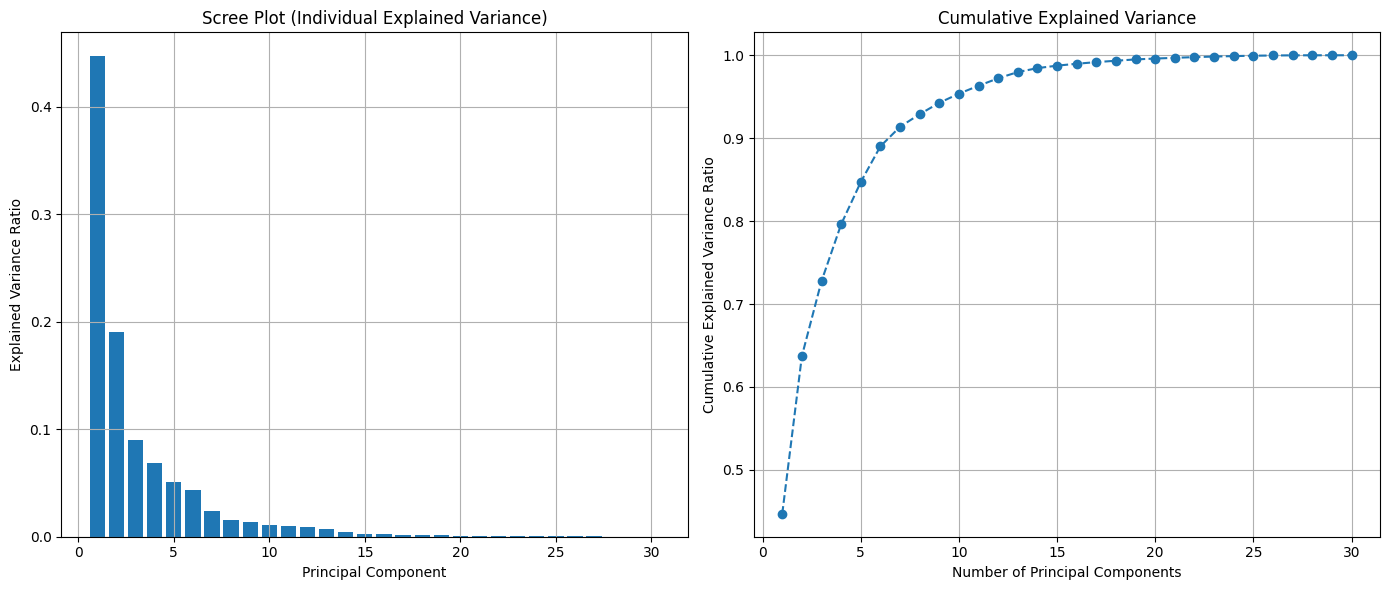

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate cumulative explained variance
cum_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(14, 6))

# Scree Plot (Individual Explained Variance)
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot (Individual Explained Variance)')
plt.grid(True)

# Cumulative Explained Variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance')
plt.grid(True)

plt.tight_layout()
plt.show()

Como podemos ver, así como he estado comentando, los primeros componentes explican la mayor varianza, mientras que los últimos explican muy poco o no explican nada de la varianza. Con la segunda gráfica, podríamos decir que podemos tener el 90% de la información con 7 componentes principales.




Ahora, para ver que podemos seguir teniendo buenas métricas con menor cantidad de información con este método entrenaremos modelos de regresión logística con una reducida cantidad de componentes principales, usando diferentes umbrales de varianza explicada acumulada (70%, 80% y 90%). Después de entrenarlos con estos umbrales, vamos a medir su desempeño en entrenamiento y prueba de PCA e imprimiremos las métricas, así como lo hicimos en los modelos anteriores. Para este caso, como vamos a comparar las métricas, agregaremos una tabla comparativa.





In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np

# Define the explained variance thresholds to test
explained_variance_thresholds = [0.70, 0.80, 0.90]

# Store results in a dictionary
results = {}

# --- Add results of the full PCA model (best_log_reg_model_pca) --- (already computed)
results['Full PCA (30 Components)'] = {
    'Train Accuracy': train_accuracy_pca,
    'Train F1 Score': train_f1_pca,
    'Train AUC': train_auc_pca,
    'Test Accuracy': test_accuracy_pca,
    'Test F1 Score': test_f1_pca,
    'Test AUC': test_auc_pca,
    'Num Components': X_train_pca.shape[1] # Should be 30
}

print("Starting classification with reduced PCA components...")

for threshold in explained_variance_thresholds:
    # Calculate the number of components for the current threshold
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.where(cumulative_variance >= threshold)[0][0] + 1

    print(f"\n--- Training model for {threshold*100:.0f}% explained variance ({n_components} components) ---")

    # Re-apply PCA with the selected number of components
    pca_reduced = PCA(n_components=n_components)
    X_train_pca_reduced = pca_reduced.fit_transform(X_train_scaled)
    X_test_pca_reduced = pca_reduced.transform(X_test_scaled)

    # Initialize Logistic Regression model and GridSearchCV
    log_reg_pca_reduced = LogisticRegression(solver='liblinear', random_state=1)
    param_grid_pca_reduced = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2']
    }

    grid_search_pca_reduced = GridSearchCV(log_reg_pca_reduced, param_grid_pca_reduced, cv=5, scoring='f1', n_jobs=-1, verbose=0)
    grid_search_pca_reduced.fit(X_train_pca_reduced, y_train)
    best_log_reg_model_pca_reduced = grid_search_pca_reduced.best_estimator_

    # Evaluate on Training Data
    y_train_pred_pca_reduced = best_log_reg_model_pca_reduced.predict(X_train_pca_reduced)
    y_train_prob_pca_reduced = best_log_reg_model_pca_reduced.predict_proba(X_train_pca_reduced)[:, 1]
    train_accuracy = accuracy_score(y_train, y_train_pred_pca_reduced)
    train_f1 = f1_score(y_train, y_train_pred_pca_reduced)
    train_auc = roc_auc_score(y_train, y_train_prob_pca_reduced)

    # Evaluate on Test Data
    y_test_pred_pca_reduced = best_log_reg_model_pca_reduced.predict(X_test_pca_reduced)
    y_test_prob_pca_reduced = best_log_reg_model_pca_reduced.predict_proba(X_test_pca_reduced)[:, 1]
    test_accuracy = accuracy_score(y_test, y_test_pred_pca_reduced)
    test_f1 = f1_score(y_test, y_test_pred_pca_reduced)
    test_auc = roc_auc_score(y_test, y_test_prob_pca_reduced)

    print(f"Best parameters: {grid_search_pca_reduced.best_params_}")
    print(f"Test Accuracy: {test_accuracy:.4f}, Test F1 Score: {test_f1:.4f}, Test AUC: {test_auc:.4f}")

    results[f'PCA ({threshold*100:.0f}% variance)'] = {
        'Train Accuracy': train_accuracy,
        'Train F1 Score': train_f1,
        'Train AUC': train_auc,
        'Test Accuracy': test_accuracy,
        'Test F1 Score': test_f1,
        'Test AUC': test_auc,
        'Num Components': n_components
    }

# --- Create and display comparative table ---
comparison_df = pd.DataFrame(results).T # Transpose to have models as rows
print("\n--- Comparative Metrics Table ---")
display(comparison_df.round(4))


Starting classification with reduced PCA components...

--- Training model for 70% explained variance (3 components) ---
Best parameters: {'C': 1, 'penalty': 'l1'}
Test Accuracy: 0.9474, Test F1 Score: 0.9573, Test AUC: 0.9888

--- Training model for 80% explained variance (5 components) ---
Best parameters: {'C': 0.1, 'penalty': 'l2'}
Test Accuracy: 0.9591, Test F1 Score: 0.9677, Test AUC: 0.9945

--- Training model for 90% explained variance (7 components) ---
Best parameters: {'C': 0.1, 'penalty': 'l2'}
Test Accuracy: 0.9532, Test F1 Score: 0.9633, Test AUC: 0.9942

--- Comparative Metrics Table ---


,Train Accuracy,Train F1 Score,Train AUC,Test Accuracy,Test F1 Score,Test AUC,Num Components
Full PCA (30 Components),0.9874,0.9901,0.9959,0.9532,0.9636,0.9958,30.0
PCA (70% variance),0.9573,0.9661,0.9919,0.9474,0.9573,0.9888,3.0
PCA (80% variance),0.9799,0.9842,0.9950,0.9591,0.9677,0.9945,5.0
PCA (90% variance),0.9799,0.9842,0.9948,0.9532,0.9633,0.9942,7.0


Como podrás ver, con tan sólo 3 componentes podemos tener métricas en entrenamiento y prueba mayores a 90%, valores muy cercanos de cuando se entrenó y probó el modelo con los 30 componentes. Esto demuestra que con tan sólo 1/10 de los componentes podemos obtener métricas muy similares a que si tuviéramos todas las variables o componentes.


Así como hicimos al principio, haremos las gráficas de densidad univariadas de los primeros 5 componentes de PCA para ver qué tan bien distinguen estos entre clases.
Usaremos las mismas funciones que antes. También, imprimiremos la gráfica de densidad del último componente.





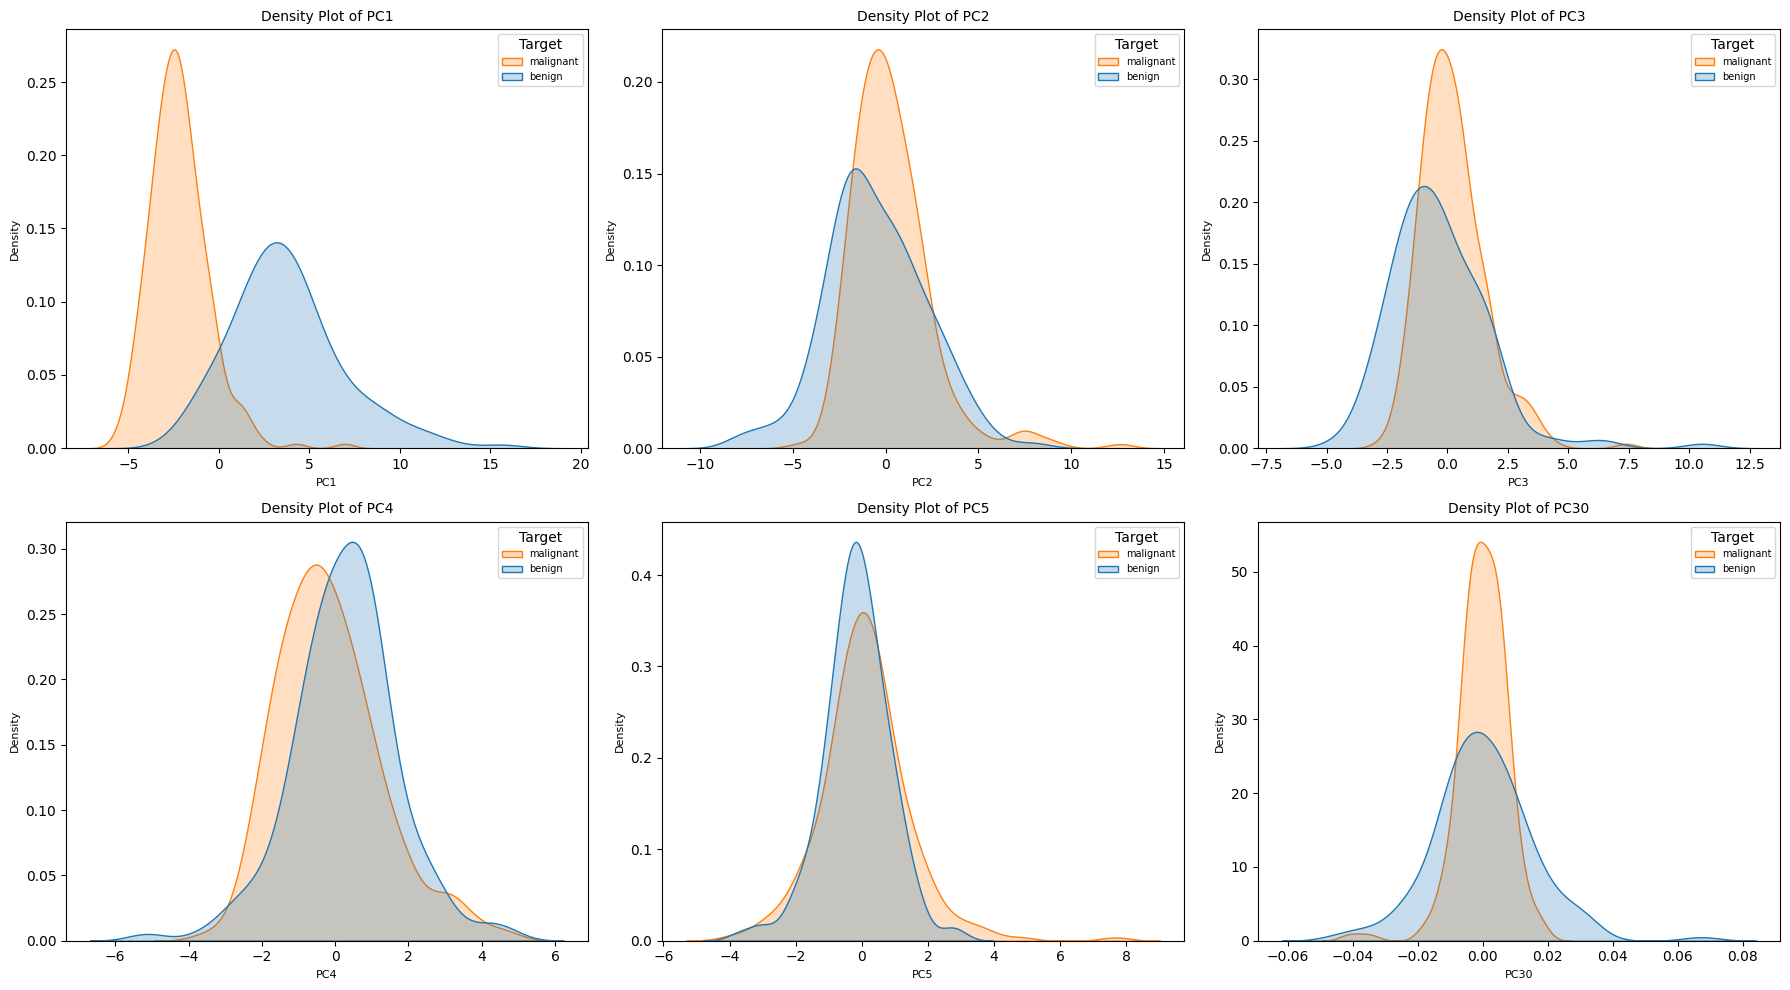

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# DataFrame con componentes
pca_components_df = pd.DataFrame(X_train_pca[:, :5], columns=[f'PC{i+1}' for i in range(5)])
pca_components_df['target'] = y_train.values

pca_pc30_df = pd.DataFrame(X_train_pca[:, 29], columns=['PC30'])
pca_pc30_df['target'] = y_train.values

plt.figure(figsize=(18, 10))

# PC1 a PC5
for i, component in enumerate(pca_components_df.columns[:-1]):
    plt.subplot(2, 3, i + 1)
    sns.kdeplot(data=pca_components_df, x=component, hue='target', fill=True, common_norm=False)
    plt.title(f'Density Plot of {component}', fontsize=10)
    plt.xlabel(component, fontsize=8)
    plt.ylabel('Density', fontsize=8)
    plt.legend(title='Target', labels=breast_cancer.target_names, fontsize=7)

# PC30
plt.subplot(2, 3, 6)
sns.kdeplot(data=pca_pc30_df, x='PC30', hue='target', fill=True, common_norm=False)
plt.title('Density Plot of PC30', fontsize=10)
plt.xlabel('PC30', fontsize=8)
plt.ylabel('Density', fontsize=8)
plt.legend(title='Target', labels=breast_cancer.target_names, fontsize=7)

plt.tight_layout()
plt.show()

Podemos ver que conforme incremente el número de componentes, más difícil se vuelve separar las clases. Esto confirma que sólo los primeros componentes realmente aportan información útil y como podemos ver, la última gráfica del componente 30 demuestra que no es útil para diferenciar entre clases.


Continuaremos haciendo 3 gráficas de dispersión con los primeros 3 componentes, así como hicimos al principio. También añadiremos la gráfica de dispersión de los últimos 2 componentes.


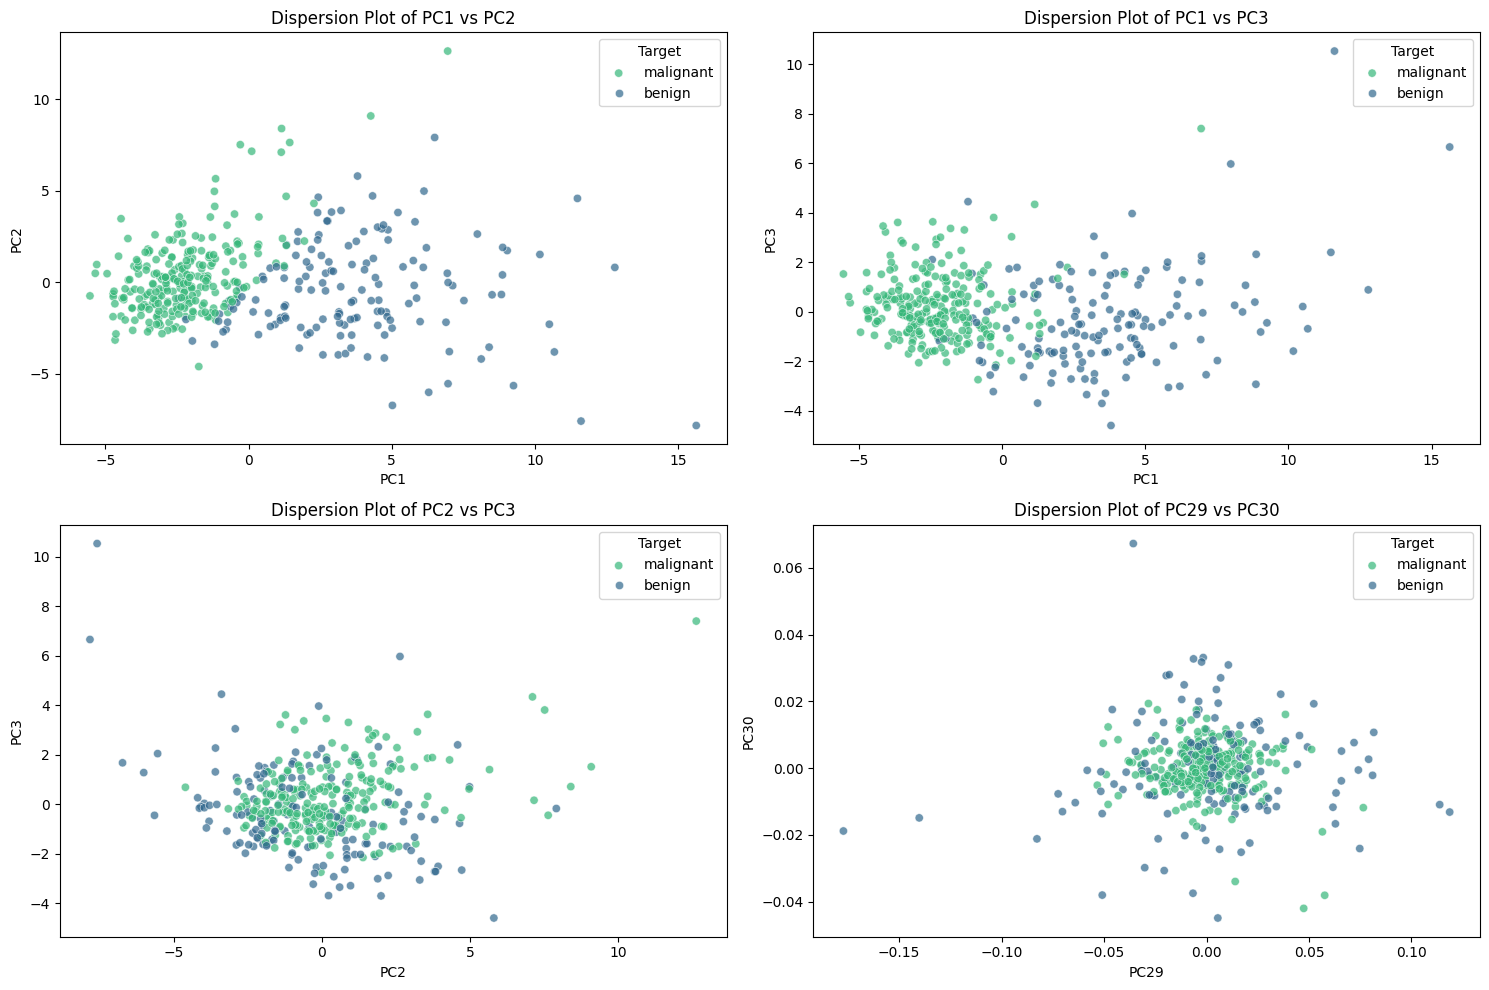

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# DataFrame para primeros componentes
pca_scatter_df = pd.DataFrame(X_train_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca_scatter_df['target'] = y_train.values

# DataFrame para componentes 29 y 30
pca_pc29_pc30_df = pd.DataFrame(X_train_pca[:, [28, 29]], columns=['PC29', 'PC30'])
pca_pc29_pc30_df['target'] = y_train.values

plt.figure(figsize=(15, 10))

# PC1 vs PC2
plt.subplot(2, 2, 1)
sns.scatterplot(data=pca_scatter_df, x='PC1', y='PC2', hue='target', palette='viridis', alpha=0.7)
plt.title('Dispersion Plot of PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Target', labels=breast_cancer.target_names)

# PC1 vs PC3
plt.subplot(2, 2, 2)
sns.scatterplot(data=pca_scatter_df, x='PC1', y='PC3', hue='target', palette='viridis', alpha=0.7)
plt.title('Dispersion Plot of PC1 vs PC3')
plt.xlabel('PC1')
plt.ylabel('PC3')
plt.legend(title='Target', labels=breast_cancer.target_names)

# PC2 vs PC3
plt.subplot(2, 2, 3)
sns.scatterplot(data=pca_scatter_df, x='PC2', y='PC3', hue='target', palette='viridis', alpha=0.7)
plt.title('Dispersion Plot of PC2 vs PC3')
plt.xlabel('PC2')
plt.ylabel('PC3')
plt.legend(title='Target', labels=breast_cancer.target_names)

# PC29 vs PC30
plt.subplot(2, 2, 4)
sns.scatterplot(data=pca_pc29_pc30_df, x='PC29', y='PC30', hue='target', palette='viridis', alpha=0.7)
plt.title('Dispersion Plot of PC29 vs PC30')
plt.xlabel('PC29')
plt.ylabel('PC30')
plt.legend(title='Target', labels=breast_cancer.target_names)

plt.tight_layout()
plt.show()

De igual manera, podemos ver que en las primeras 2 gráficas (Componente 1 vs Componente 2 y Componente 1 vs Componente 3) sí se pueden separar las clases un poco mejor que en la tercer gráfica (Componente 2 y Componente 3) y la cuarta gráfica (Componente 29 y Componente 30). Esto también indica que entre más se avanza en los componentes menos información importante aportan.


---
Tal vez te estarás preguntando "¿Y esto cómo se interpreta?". Y sí, estamos perdiendo un poco de interpretabilidad. Pero podemos interpretarlo con los loadings (pesos). Estos son los pesos de cada variable en cada componente principal. Entonces, calcularemos e imprimiremos los valores de estos pesos de los primeros 4 PC para poder tener una mejor interpretación del modelo.


Para esto, usaremos la función `.components_[:4]`, indicando que sólo queremos los loadings para los primeros 4 componentes. Luego usamos un `for` loop para pasar por estos 4 componentes, acomodar en orden las variables de la que más tiene influencia en el componente a la que menos tiene (por valor absoluto) y luego imprimiéndolas.





In [ ]:
pca_loadings = pd.DataFrame(pca.components_[:4], columns=X_train_scaled.columns, index=[f'PC{i+1}' for i in range(4)])

print("Loadings for the first 4 Principal Components (sorted by absolute value):\n")

for i in range(len(pca_loadings)):
    pc_name = f'PC{i+1}'
    # Sort by absolute value for better interpretation
    sorted_loadings = pca_loadings.loc[pc_name].abs().sort_values(ascending=False)
    # Get the original loadings in the sorted order
    sorted_loadings_original_values = pca_loadings.loc[pc_name][sorted_loadings.index]
    print(f"--- {pc_name} ---")
    display(sorted_loadings_original_values.to_frame())
    print("\n")

Loadings for the first 4 Principal Components (sorted by absolute value):

--- PC1 ---


,PC1
mean concave points,0.259150
mean concavity,0.258504
worst concave points,0.250368
mean compactness,0.241897
worst perimeter,0.237074
worst concavity,0.231432
worst radius,0.228609
mean perimeter,0.227872
worst area,0.225339
mean area,0.221555




--- PC2 ---


,PC2
mean fractal dimension,0.360563
fractal dimension error,0.293608
worst fractal dimension,0.275214
compactness error,0.234575
mean radius,-0.229752
mean area,-0.227213
smoothness error,0.221023
worst radius,-0.214745
worst area,-0.213805
mean perimeter,-0.211716




--- PC3 ---


,PC3
texture error,0.390509
smoothness error,0.297639
radius error,0.294368
perimeter error,0.293230
symmetry error,0.287485
worst symmetry,-0.256807
worst smoothness,-0.243935
area error,0.242515
worst compactness,-0.231875
concave points error,0.220949




--- PC4 ---


,PC4
worst texture,0.627911
mean texture,0.602690
texture error,0.357999
mean smoothness,-0.178128
area error,-0.116665
radius error,-0.104176
perimeter error,-0.094506
worst compactness,0.088668
worst concavity,0.078110
worst fractal dimension,0.064399


Para el primer componente, las 4 variables que lo afectan fuertemente son `mean concave points`, `mean concavity`, `worst concave points` y `mean compactness`. Luego, para el segundo componente tenemos las variables que más lo afectan son `mean fractal dimension error`, `fractal dimension error`, `worst fractal dimension error` y `compactness error`. Después, para el componente 3 tenemos que las variables que más afectan a éste son `texture error`, `smoothness error`, `radius error`y `perimeter error`. Por último, para el cuarto componente las variables que más afectan son `worst texture`, `mean texture`, `texture error` y `mean smoothness`.


Como se puede ver, cada componente es afectado mayormente por cierto grupo de características. Por ejemplo, el componente uno captura la forma e irregularidad del tumor. El componente 2 captura errores de las mediciones y de la geometría. El componente 3 captura los errores. Y el componente 4 captura la textura y suavidad de la muestra.


---
Con este ejemplo ahora podrás ver más claramente que utilizar PCA ayuda mucho para reducir la cantidad de variables sin perder tanta información. También pudimos ver que los componentes son independientes uno de otros, al igual que los primeros componentes explican más varianza que los últimos componentes. Comprobamos que podemos captura gran parte de la información con tan sólo 1/10 de la cantidad de componentes originales (en este caso), obteniendo métricas para el modelo muy similares a cuando se entrenaba con todos los componentes. Este puede ser un método utilizado para comprimir información perdiendo pocos de los datos dentro de ella.


---


#### **Sistemas de Recomendación**


A continuación se añadirá el código realizado en clase para comprender el funcionamiento de este sistema de recomendación. Al final se añadirá una "app" para realizar recomendaciones en base a tus calificaciones.





In [ ]:
import pandas as pd
from sklearn.datasets import load_wine

# Load the wine dataset
wine = load_wine()

# Create a DataFrame for easier inspection
# The data contains feature values, and the target contains the class labels
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target

### Dataset Characteristics

In [ ]:
print("Shape of the dataset (rows, columns):", df.shape)
print("\nData types and non-null values:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nTarget classes:", wine.target_names)

Shape of the dataset (rows, columns): (178, 14)

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (124, 13)
X_test shape: (54, 13)
y_train shape: (124,)
y_test shape: (54,)


In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optionally, convert scaled arrays back to DataFrames for easier inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nFirst 5 rows of scaled training features:")
display(X_train_scaled_df.head())
print("\nFirst 5 rows of scaled test features:")
display(X_test_scaled_df.head())


First 5 rows of scaled training features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
90,-1.104538,-0.530902,-0.136257,-0.374157,-1.294014,-1.017096,-0.444344,1.266120,0.159532,-1.074295,0.516454,-0.418240,-0.851947
95,-0.608849,-0.792240,-0.573221,-0.217310,4.793609,0.421716,0.331268,-0.403193,2.946675,-0.990146,0.856550,0.076074,0.739762
28,1.170548,-0.471890,1.611596,-0.091832,0.660038,1.141122,1.036369,0.014135,0.363469,-0.190727,1.239159,1.133355,0.663137
124,-1.371448,1.559801,0.118638,0.410080,-1.218858,0.997241,1.096806,-1.321315,2.317869,-0.905997,-0.886446,1.462898,-1.200242
135,-0.443619,0.000204,-0.573221,-0.374157,-0.316988,-0.985122,-1.290465,2.184241,-1.030103,0.903214,-0.971470,-1.365674,-0.103112



First 5 rows of scaled test features:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
161,0.941768,0.674624,0.664842,0.096385,0.660038,-0.649399,-1.391194,1.099188,-1.268030,0.389903,0.006308,-1.036132,-0.155356
117,-0.672399,-0.716368,-0.609634,0.880623,0.735194,-0.377624,0.149956,-0.236262,0.108547,-1.217349,0.431429,0.529194,-1.322145
19,0.878219,0.539740,0.737669,-1.409351,1.336440,0.741452,1.096806,-1.655177,0.193521,0.061721,0.006308,1.078432,0.419330
69,-0.939308,-1.070438,-2.211834,-0.907439,3.966895,-0.617426,-0.665947,-1.905574,1.621083,-0.884959,1.366696,0.680235,-0.023004
53,1.043448,-0.471890,1.174633,-0.813330,1.261285,1.221056,0.855057,0.181067,0.227511,0.566617,0.729014,0.488002,2.265294


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier

# Initialize the Logistic Regression model
# Using 'liblinear' solver for multiclass classification as it handles L1/L2 penalties well
# The previous warning about 'multi_class' is addressed by using OneVsRestClassifier.
model = OneVsRestClassifier(LogisticRegression(random_state=1, solver='liblinear'))

# Train the model on the scaled training data
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

# Calculate F1-score (for multiclass, use 'weighted' average)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score (weighted): {f1:.4f}")

# Calculate AUC score (for multiclass, use 'ovr' strategy with 'weighted' average)
# Need predicted probabilities for AUC
y_pred_proba = model.predict_proba(X_test_scaled)
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
print(f"AUC Score (weighted, One-vs-Rest): {auc:.4f}")

Accuracy Score: 1.0000
F1 Score (weighted): 1.0000
AUC Score (weighted, One-vs-Rest): 1.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create copies to introduce missing values, so original scaled data remains intact
X_train_scaled_df_missing = X_train_scaled_df.copy()
X_test_scaled_df_missing = X_test_scaled_df.copy()

# Function to introduce missing values randomly
def introduce_random_nan(df, missing_percentage):
    df_copy = df.copy()
    total_cells = df_copy.size
    num_nan_to_introduce = int(total_cells * missing_percentage)

    # Get all possible (row, column) index pairs
    rows, cols = df_copy.shape
    all_indices = [(r, c) for r in range(rows) for c in range(cols)]

    # Randomly sample indices to set to NaN without replacement
    # Using numpy.random.choice with replace=False for unique indices
    # Need to flatten the list of tuples and then reshape for column and row indices
    nan_indices_flat = np.random.choice(len(all_indices), num_nan_to_introduce, replace=False)

    for i in nan_indices_flat:
        r, c = all_indices[i]
        df_copy.iloc[r, c] = np.nan
    return df_copy

# Introduce 30% missing values in X_train_scaled_df_missing
X_train_scaled_df_missing = introduce_random_nan(X_train_scaled_df_missing, 0.3)

# Introduce 30% missing values in X_test_scaled_df_missing
X_test_scaled_df_missing = introduce_random_nan(X_test_scaled_df_missing, 0.3)

print("Shape of X_train_scaled_df_missing with NaNs:", X_train_scaled_df_missing.shape)
print("Number of missing values in X_train_scaled_df_missing:", X_train_scaled_df_missing.isnull().sum().sum())
print("Shape of X_test_scaled_df_missing with NaNs:", X_test_scaled_df_missing.shape)
print("Number of missing values in X_test_scaled_df_missing:", X_test_scaled_df_missing.isnull().sum().sum())

Shape of X_train_scaled_df_missing with NaNs: (124, 13)
Number of missing values in X_train_scaled_df_missing: 483
Shape of X_test_scaled_df_missing with NaNs: (54, 13)
Number of missing values in X_test_scaled_df_missing: 210


### Heatmaps of Missing Values

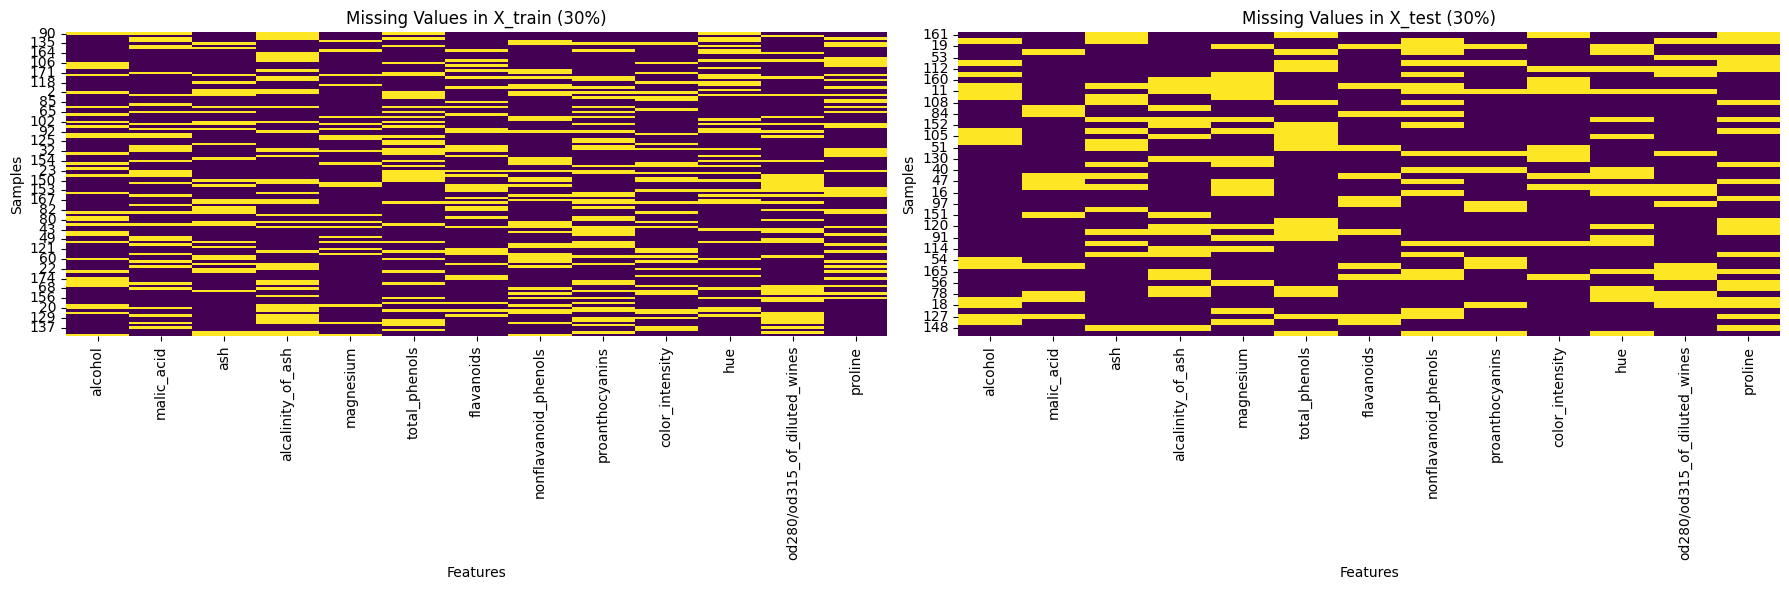

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap for Training Data Missing Values
sns.heatmap(X_train_scaled_df_missing.isnull(), cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values in X_train (30%)')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Samples')

# Heatmap for Test Data Missing Values
sns.heatmap(X_test_scaled_df_missing.isnull(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values in X_test (30%)')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Samples')

plt.tight_layout()
plt.show()

### Imputation Using Mean

In [ ]:
from sklearn.impute import SimpleImputer

# Initialize SimpleImputer with mean strategy
mean_imputer = SimpleImputer(strategy='mean')

# Fit on training data and transform both training and test data
X_train_mean_imputed = mean_imputer.fit_transform(X_train_scaled_df_missing)
X_test_mean_imputed = mean_imputer.transform(X_test_scaled_df_missing)

print("Shape of X_train after mean imputation:", X_train_mean_imputed.shape)
print("Number of missing values in X_train after mean imputation:", pd.DataFrame(X_train_mean_imputed).isnull().sum().sum())
print("Shape of X_test after mean imputation:", X_test_mean_imputed.shape)
print("Number of missing values in X_test after mean imputation:", pd.DataFrame(X_test_mean_imputed).isnull().sum().sum())

Shape of X_train after mean imputation: (124, 13)
Number of missing values in X_train after mean imputation: 0
Shape of X_test after mean imputation: (54, 13)
Number of missing values in X_test after mean imputation: 0


### Logistic Regression Model with mean Imputation

In [ ]:
# Initialize the Logistic Regression model (with OneVsRestClassifier for multiclass)
model_mean_imputed = OneVsRestClassifier(LogisticRegression(random_state=1, solver='liblinear'))

# Train the model on the mean-imputed training data
model_mean_imputed.fit(X_train_mean_imputed, y_train)

# Make predictions on the mean-imputed training and test data
y_train_pred_mean = model_mean_imputed.predict(X_train_mean_imputed)
y_test_pred_mean = model_mean_imputed.predict(X_test_mean_imputed)

# Get probabilities for AUC calculation
y_train_pred_proba_mean = model_mean_imputed.predict_proba(X_train_mean_imputed)
y_test_pred_proba_mean = model_mean_imputed.predict_proba(X_test_mean_imputed)

print("--- Metrics for Mean Imputation ---")

# Training Metrics
print("\nTraining Metrics:")
print(f"Accuracy Score (Train): {accuracy_score(y_train, y_train_pred_mean):.4f}")
print(f"F1 Score (Train, weighted): {f1_score(y_train, y_train_pred_mean, average='weighted'):.4f}")
print(f"AUC Score (Train, weighted, One-vs-Rest): {roc_auc_score(y_train, y_train_pred_proba_mean, multi_class='ovr', average='weighted'):.4f}")

# Test Metrics
print("\nTest Metrics:")
print(f"Accuracy Score (Test): {accuracy_score(y_test, y_test_pred_mean):.4f}")
print(f"F1 Score (Test, weighted): {f1_score(y_test, y_test_pred_mean, average='weighted'):.4f}")
print(f"AUC Score (Test, weighted, One-vs-Rest): {roc_auc_score(y_test, y_test_pred_proba_mean, multi_class='ovr', average='weighted'):.4f}")

--- Metrics for Mean Imputation ---

Training Metrics:
Accuracy Score (Train): 0.9516
F1 Score (Train, weighted): 0.9516
AUC Score (Train, weighted, One-vs-Rest): 0.9922

Test Metrics:
Accuracy Score (Test): 0.9259
F1 Score (Test, weighted): 0.9271
AUC Score (Test, weighted, One-vs-Rest): 1.0000


### Imputation using KNN

In [ ]:
from sklearn.impute import KNNImputer

# Initialize KNNImputer
knn_imputer = KNNImputer(n_neighbors=5) # Using 5 neighbors as a common starting point

# Fit on training data and transform both training and test data
X_train_knn_imputed = knn_imputer.fit_transform(X_train_scaled_df_missing)
X_test_knn_imputed = knn_imputer.transform(X_test_scaled_df_missing)

print("Shape of X_train after KNN imputation:", X_train_knn_imputed.shape)
print("Number of missing values in X_train after KNN imputation:", pd.DataFrame(X_train_knn_imputed).isnull().sum().sum())
print("Shape of X_test after KNN imputation:", X_test_knn_imputed.shape)
print("Number of missing values in X_test after KNN imputation:", pd.DataFrame(X_test_knn_imputed).isnull().sum().sum())

Shape of X_train after KNN imputation: (124, 13)
Number of missing values in X_train after KNN imputation: 0
Shape of X_test after KNN imputation: (54, 13)
Number of missing values in X_test after KNN imputation: 0


Logistic Regression Model with KNN Imputation

In [ ]:
# Initialize the Logistic Regression model (with OneVsRestClassifier for multiclass)
model_knn_imputed = OneVsRestClassifier(LogisticRegression(random_state=1, solver='liblinear'))

# Train the model on the KNN-imputed training data
model_knn_imputed.fit(X_train_knn_imputed, y_train)

# Make predictions on the KNN-imputed training and test data
y_train_pred_knn = model_knn_imputed.predict(X_train_knn_imputed)
y_test_pred_knn = model_knn_imputed.predict(X_test_knn_imputed)

# Get probabilities for AUC calculation
y_train_pred_proba_knn = model_knn_imputed.predict_proba(X_train_knn_imputed)
y_test_pred_proba_knn = model_knn_imputed.predict_proba(X_test_knn_imputed)

print("--- Metrics for KNN Imputation ---")

# Training Metrics
print("\nTraining Metrics:")
print(f"Accuracy Score (Train): {accuracy_score(y_train, y_train_pred_knn):.4f}")
print(f"F1 Score (Train, weighted): {f1_score(y_train, y_train_pred_knn, average='weighted'):.4f}")
print(f"AUC Score (Train, weighted, One-vs-Rest): {roc_auc_score(y_train, y_train_pred_proba_knn, multi_class='ovr', average='weighted'):.4f}")

# Test Metrics
print("\nTest Metrics:")
print(f"Accuracy Score (Test): {accuracy_score(y_test, y_test_pred_knn):.4f}")
print(f"F1 Score (Test, weighted): {f1_score(y_test, y_test_pred_knn, average='weighted'):.4f}")
print(f"AUC Score (Test, weighted, One-vs-Rest): {roc_auc_score(y_test, y_test_pred_proba_knn, multi_class='ovr', average='weighted'):.4f}")

--- Metrics for KNN Imputation ---

Training Metrics:
Accuracy Score (Train): 0.9274
F1 Score (Train, weighted): 0.9274
AUC Score (Train, weighted, One-vs-Rest): 0.9948

Test Metrics:
Accuracy Score (Test): 0.9815
F1 Score (Test, weighted): 0.9814
AUC Score (Test, weighted, One-vs-Rest): 0.9995


In [ ]:
pip install fancyimpute

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.6 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29879 sha256=ee78669fa7e357f9d5fdf203f83b0ef1a76f677009b5e19fa7ad1c5a81b9e90f
  Stored in directory: /root/.cache/pip/wheels/df/20/91/e4850b9a31cf660c1bc95515d3bcbc8010e869e5de6d5baf07
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11331 sha256=aef3c99eb40dac9adb3f83cf093566aab59dc4137ec88e0bd975ccc6429c3cf2
  Stored in directory: /root/.cache/pip/wheels/89/11/61/aa5a3167bfff49218cd043a73a83034b9eadd858b0059521be
Successfully built fancyimpute knnimpute


### Imputation using SoftImpute (Iterative PCA)

In [ ]:
from fancyimpute import SoftImpute
import pandas as pd

# Initialize SoftImpute for training data
soft_imputer_train = SoftImpute(max_iters=100, verbose=False)

# Fit on training data and transform it
X_train_soft_imputed = soft_imputer_train.fit_transform(X_train_scaled_df_missing.values)

# For test data, we must create a new imputer and fit_transform it,
# as SoftImpute does not have a 'transform' method for inductive mode.
# This approach ensures no data leakage from the training set.
soft_imputer_test = SoftImpute(max_iters=100, verbose=False)
X_test_soft_imputed = soft_imputer_test.fit_transform(X_test_scaled_df_missing.values)

print("Shape of X_train after SoftImpute imputation:", X_train_soft_imputed.shape)
print("Number of missing values in X_train after SoftImpute imputation:", pd.DataFrame(X_train_soft_imputed).isnull().sum().sum())
print("Shape of X_test after SoftImpute imputation:", X_test_soft_imputed.shape)
print("Number of missing values in X_test after SoftImpute imputation:", pd.DataFrame(X_test_soft_imputed).isnull().sum().sum())

Shape of X_train after SoftImpute imputation: (124, 13)
Number of missing values in X_train after SoftImpute imputation: 0
Shape of X_test after SoftImpute imputation: (54, 13)
Number of missing values in X_test after SoftImpute imputation: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

### Logistic Regression Model with SoftImpute

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier

# Initialize the Logistic Regression model (with OneVsRestClassifier for multiclass)
model_soft_imputed = OneVsRestClassifier(LogisticRegression(random_state=1, solver='liblinear'))

# Train the model on the SoftImpute-imputed training data
model_soft_imputed.fit(X_train_soft_imputed, y_train)

# Make predictions on the SoftImpute-imputed training and test data
y_train_pred_soft = model_soft_imputed.predict(X_train_soft_imputed)
y_test_pred_soft = model_soft_imputed.predict(X_test_soft_imputed)

# Get probabilities for AUC calculation
y_train_pred_proba_soft = model_soft_imputed.predict_proba(X_train_soft_imputed)
y_test_pred_proba_soft = model_soft_imputed.predict_proba(X_test_soft_imputed)

print("--- Metrics for SoftImpute ---")

# Training Metrics
print("\nTraining Metrics:")
print(f"Accuracy Score (Train): {accuracy_score(y_train, y_train_pred_soft):.4f}")
print(f"F1 Score (Train, weighted): {f1_score(y_train, y_train_pred_soft, average='weighted'):.4f}")
print(f"AUC Score (Train, weighted, One-vs-Rest): {roc_auc_score(y_train, y_train_pred_proba_soft, multi_class='ovr', average='weighted'):.4f}")

# Test Metrics
print("\nTest Metrics:")
print(f"Accuracy Score (Test): {accuracy_score(y_test, y_test_pred_soft):.4f}")
print(f"F1 Score (Test, weighted): {f1_score(y_test, y_test_pred_soft, average='weighted'):.4f}")
print(f"AUC Score (Test, weighted, One-vs-Rest): {roc_auc_score(y_test, y_test_pred_proba_soft, multi_class='ovr', average='weighted'):.4f}")

--- Metrics for SoftImpute ---

Training Metrics:
Accuracy Score (Train): 0.9677
F1 Score (Train, weighted): 0.9679
AUC Score (Train, weighted, One-vs-Rest): 0.9924

Test Metrics:
Accuracy Score (Test): 1.0000
F1 Score (Test, weighted): 1.0000
AUC Score (Test, weighted, One-vs-Rest): 1.0000


### Imputation Reconstruction Error

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

print("--- Reconstruction Errors (RMSE) for Imputation Methods ---")

# Function to calculate RMSE for original missing values
def calculate_imputation_rmse(original_df, missing_df, imputed_array):
    # Identify the positions of missing values
    missing_mask = missing_df.isnull().values

    # Extract original values at these positions
    original_values = original_df.values[missing_mask]

    # Extract imputed values at these positions
    imputed_values = imputed_array[missing_mask]

    # Calculate RMSE
    if len(original_values) > 0:
        return np.sqrt(mean_squared_error(original_values, imputed_values))
    else:
        return 0.0 # No missing values to reconstruct

# --- Mean Imputation Error ---
rmse_mean_train = calculate_imputation_rmse(X_train_scaled_df, X_train_scaled_df_missing, X_train_mean_imputed)
rmse_mean_test = calculate_imputation_rmse(X_test_scaled_df, X_test_scaled_df_missing, X_test_mean_imputed)
print(f"\nMean Imputation (RMSE for missing values) - Train: {rmse_mean_train:.4f}, Test: {rmse_mean_test:.4f}")

# --- KNN Imputation Error ---
rmse_knn_train = calculate_imputation_rmse(X_train_scaled_df, X_train_scaled_df_missing, X_train_knn_imputed)
rmse_knn_test = calculate_imputation_rmse(X_test_scaled_df, X_test_scaled_df_missing, X_test_knn_imputed)
print(f"KNN Imputation (RMSE for missing values) - Train: {rmse_knn_train:.4f}, Test: {rmse_knn_test:.4f}")

# --- SoftImpute Error ---
rmse_soft_train = calculate_imputation_rmse(X_train_scaled_df, X_train_scaled_df_missing, X_train_soft_imputed)
rmse_soft_test = calculate_imputation_rmse(X_test_scaled_df, X_test_scaled_df_missing, X_test_soft_imputed)
print(f"SoftImpute (RMSE for missing values) - Train: {rmse_soft_train:.4f}, Test: {rmse_soft_test:.4f}")

--- Reconstruction Errors (RMSE) for Imputation Methods ---

Mean Imputation (RMSE for missing values) - Train: 1.0358, Test: 0.9783
KNN Imputation (RMSE for missing values) - Train: 0.8215, Test: 0.7535
SoftImpute (RMSE for missing values) - Train: 0.7997, Test: 0.7920


---
Movie data set

### Loading `u.item` and `u.data`

In [ ]:
import pandas as pd

# Load u.item (movie information) - common separator is '|'
# The column names are based on the MovieLens 100k dataset documentation.
item_cols = ['movie_id', 'movie_title', 'release_date', 'video_release_date', 'imdb_url',
             'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
             'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
             'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

u_item_df = pd.read_csv('/content/u.item', sep='|', names=item_cols, encoding='latin-1')

# Load u.data (ratings data) - common separator is '\t'
# The column names are based on the MovieLens 100k dataset documentation.
# The 'timestamp' column will be parsed later if needed.
data_cols = ['user_id', 'movie_id', 'rating', 'timestamp']

u_data_df = pd.read_csv('/content/u.data', sep='\t', names=data_cols)

print("First 5 rows of u.item:")
display(u_item_df.head())
print("\nFirst 5 rows of u.data:")
display(u_data_df.head())

First 5 rows of u.item:


,movie_id,movie_title,release_date,video_release_date,imdb_url,unknown,Action,Adventure,Animation,Childrens,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0



First 5 rows of u.data:


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


### Characteristics of `u.item`

In [ ]:
print("Shape of u.item (rows, columns):", u_item_df.shape)
print("\nData types and non-null values for u.item:")
u_item_df.info()

print("\nMissing values per column in u.item:")
print(u_item_df.isnull().sum())

Shape of u.item (rows, columns): (1682, 24)

Data types and non-null values for u.item:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_id            1682 non-null   int64  
 1   movie_title         1682 non-null   object 
 2   release_date        1681 non-null   object 
 3   video_release_date  0 non-null      float64
 4   imdb_url            1679 non-null   object 
 5   unknown             1682 non-null   int64  
 6   Action              1682 non-null   int64  
 7   Adventure           1682 non-null   int64  
 8   Animation           1682 non-null   int64  
 9   Childrens           1682 non-null   int64  
 10  Comedy              1682 non-null   int64  
 11  Crime               1682 non-null   int64  
 12  Documentary         1682 non-null   int64  
 13  Drama               1682 non-null   int64  
 14  Fantasy         

### Characteristics of `u.data`

In [ ]:
print("Shape of u.data (rows, columns):", u_data_df.shape)
print("\nData types and non-null values for u.data:")
u_data_df.info()

print("\nMissing values per column in u.data:")
print(u_data_df.isnull().sum())

Shape of u.data (rows, columns): (100000, 4)

Data types and non-null values for u.data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB

Missing values per column in u.data:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64


### Creating User-Item Matrix and Visualizing Missing Values

Shape of user-item matrix: (943, 1682)
First 5 rows of user-item matrix (with NaNs for missing ratings):


movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


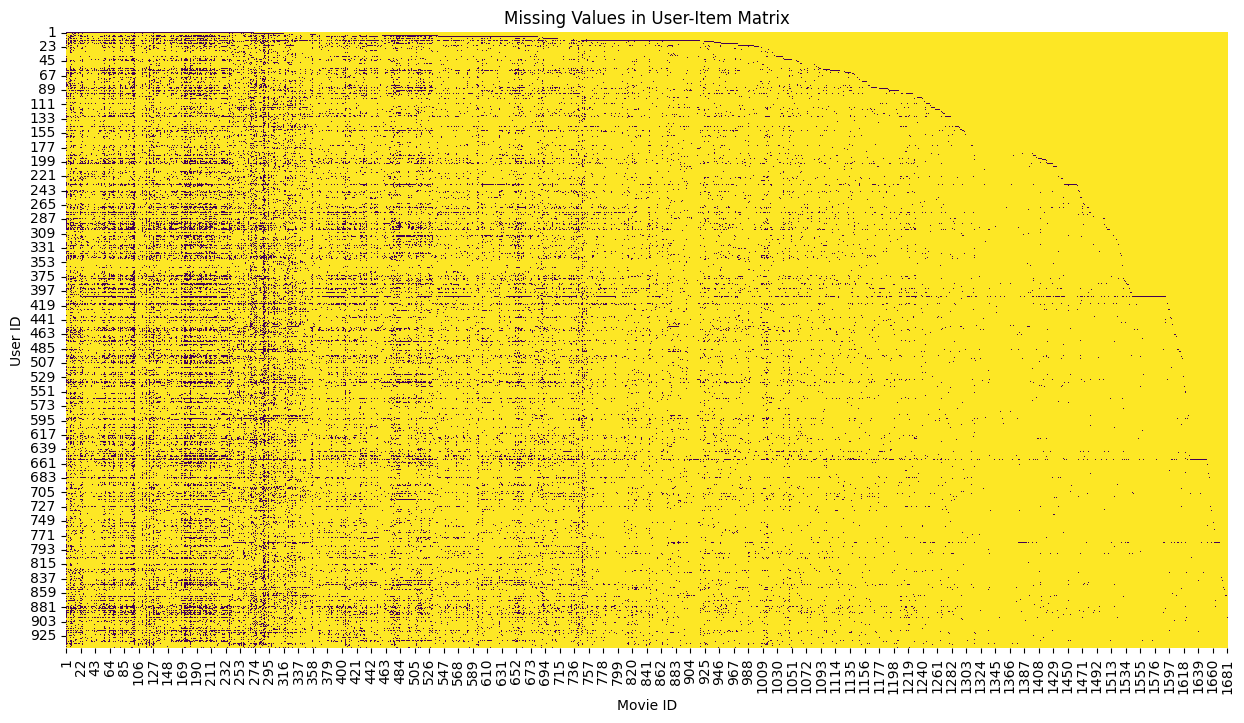


Total number of missing values (NaNs) in the user-item matrix: 1486126
Percentage of missing values: 93.70%


In [ ]:
# Create the user-item matrix
user_item_matrix = u_data_df.pivot_table(index='user_id', columns='movie_id', values='rating')

print("Shape of user-item matrix:", user_item_matrix.shape)
print("First 5 rows of user-item matrix (with NaNs for missing ratings):")
display(user_item_matrix.head())

# Visualize missing values with a heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.heatmap(user_item_matrix.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in User-Item Matrix')
plt.xlabel('Movie ID')
plt.ylabel('User ID')
plt.show()

# Print the total amount of missing data
total_missing_values = user_item_matrix.isnull().sum().sum()
total_cells = user_item_matrix.size
missing_percentage = (total_missing_values / total_cells) * 100

print(f"\nTotal number of missing values (NaNs) in the user-item matrix: {total_missing_values}")
print(f"Percentage of missing values: {missing_percentage:.2f}%")

### Hiding 10% of Ratings and User-Centering

In [ ]:
import numpy as np

# Create a copy of the user-item matrix to introduce new missing values for simulation
user_item_matrix_for_imputation = user_item_matrix.copy()

# Find all non-NaN indices (user_id, movie_id tuples)
non_nan_indices = user_item_matrix_for_imputation.stack().index

# Calculate 10% of non-NaN values to hide
num_to_hide = int(len(non_nan_indices) * 0.10)

# Randomly select indices to hide for reproducibility
np.random.seed(42)
indices_to_hide = np.random.choice(len(non_nan_indices), num_to_hide, replace=False)

# Store the original values of the hidden ratings and set them to NaN in the matrix
hidden_ratings_df = pd.DataFrame(columns=['user_id', 'movie_id', 'original_rating'])

for i in indices_to_hide:
    user_id, movie_id = non_nan_indices[i]
    original_rating = user_item_matrix_for_imputation.loc[user_id, movie_id]
    hidden_ratings_df = pd.concat([hidden_ratings_df, pd.DataFrame([{'user_id': user_id, 'movie_id': movie_id, 'original_rating': original_rating}])], ignore_index=True)
    user_item_matrix_for_imputation.loc[user_id, movie_id] = np.nan

print(f"Number of non-NaN values originally: {len(user_item_matrix.stack())}")
print(f"Number of values newly hidden: {len(hidden_ratings_df)}")
print(f"Number of non-NaN values after hiding: {len(user_item_matrix_for_imputation.stack())}")

print("\nFirst 5 newly hidden ratings:")
display(hidden_ratings_df.head())

/tmp/ipykernel_28075/1066321961.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  hidden_ratings_df = pd.concat([hidden_ratings_df, pd.DataFrame([{'user_id': user_id, 'movie_id': movie_id, 'original_rating': original_rating}])], ignore_index=True)


Number of non-NaN values originally: 100000
Number of values newly hidden: 10000
Number of non-NaN values after hiding: 90000

First 5 newly hidden ratings:


,user_id,movie_id,original_rating
0,693,382,4.0
1,747,111,4.0
2,201,212,4.0
3,705,427,2.0
4,880,849,3.0


In [ ]:
# Center the ratings for each user based on their available ratings
# Calculate the mean rating for each user, ignoring NaN values
user_means = user_item_matrix_for_imputation.mean(axis=1)

# Subtract the user's mean from their ratings to center them
# NaNs will remain NaN after this operation
user_item_matrix_centered = user_item_matrix_for_imputation.sub(user_means, axis=0)

print("\nFirst 5 rows of the user-item matrix after hiding 10% and centering (with hidden values as NaNs):")
display(user_item_matrix_centered.head())

print(f"\nTotal number of missing values (NaNs) in the centered user-item matrix: {user_item_matrix_centered.isnull().sum().sum()}")
print(f"Percentage of missing values in centered matrix: {(user_item_matrix_centered.isnull().sum().sum() / user_item_matrix_centered.size) * 100:.2f}%")


First 5 rows of the user-item matrix after hiding 10% and centering (with hidden values as NaNs):


movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.372951,-0.627049,0.372951,-0.627049,-0.627049,1.372951,0.372951,-2.627049,1.372951,-0.627049,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.315789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.684211,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.152866,0.152866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Total number of missing values (NaNs) in the centered user-item matrix: 1496126
Percentage of missing values in centered matrix: 94.33%


### Imputation using SoftImpute on Uncentered Data and Re-centering

In [ ]:

# Initialize SoftImpute
# Note: SoftImpute expects a numpy array. The verbose=False suppresses iteration output.
soft_imputer_movie = SoftImpute(max_iters=100, verbose=False)

# Perform imputation on the user-item matrix (which contains the original NaNs and the 10% hidden NaNs)
# It's important to use the uncentered matrix for imputation so original scale of ratings is preserved.
# The result is a numpy array, convert back to DataFrame for easier handling.
imputed_matrix_soft = soft_imputer_movie.fit_transform(user_item_matrix_for_imputation.values)
imputed_user_item_df = pd.DataFrame(imputed_matrix_soft,
                                      index=user_item_matrix_for_imputation.index,
                                      columns=user_item_matrix_for_imputation.columns)

print("First 5 rows of the SoftImpute-imputed user-item matrix (uncentered initial values):")
display(imputed_user_item_df.head())

print(f"Total number of missing values after SoftImpute: {imputed_user_item_df.isnull().sum().sum()}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


First 5 rows of the SoftImpute-imputed user-item matrix (uncentered initial values):


movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.000000,3.000000,4.000000,3.000000,3.000000,5.000000,4.000000,1.000000,5.000000,3.000000,...,0.171675,0.483032,0.263183,0.175455,0.303494,0.008357,0.025070,0.016713,0.236764,0.592231
2,4.000000,0.602275,1.447983,1.360388,0.801205,2.189548,3.353829,2.102825,4.046348,2.000000,...,0.097085,0.113042,0.200720,0.133814,0.146594,0.055394,0.166181,0.110787,0.073191,0.045505
3,1.756420,0.401070,1.068729,1.051648,0.706871,0.400610,2.078393,0.918268,2.276300,0.772749,...,-0.046847,0.020344,0.332408,0.221605,0.086383,0.113462,0.340387,0.226924,0.060475,0.024670
4,2.724814,0.337192,1.140933,1.208246,0.793448,0.617984,2.635500,1.440669,2.921159,0.945850,...,0.001802,-0.075422,0.212159,0.141439,0.006067,0.167105,0.501316,0.334210,0.073292,-0.063224
5,4.000000,3.000000,1.517631,3.134162,2.477683,1.382927,4.214021,3.740199,2.148434,3.117615,...,0.091815,0.319724,0.281771,0.187847,0.285371,-0.038182,-0.114547,-0.076365,0.271266,0.279506


Total number of missing values after SoftImpute: 0


### Re-centering the Imputed Matrix

In [ ]:
# Calculate the mean rating for each user from the *fully imputed* matrix
# This gives a 'true' mean after all missing values (including the hidden ones) have been filled.
user_means_imputed = imputed_user_item_df.mean(axis=1)

# Subtract these new user means from the fully imputed matrix to re-center it
imputed_user_item_df_centered = imputed_user_item_df.sub(user_means_imputed, axis=0)

print("First 5 rows of the SoftImpute-imputed and re-centered user-item matrix:")
display(imputed_user_item_df_centered.head())

First 5 rows of the SoftImpute-imputed and re-centered user-item matrix:


movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,2.909283,0.909283,1.909283,0.909283,0.909283,2.909283,1.909283,-1.090717,2.909283,0.909283,...,-1.919042,-1.607685,-1.827534,-1.915261,-1.787223,-2.082360,-2.065647,-2.074004,-1.853953,-1.498485
2,2.974434,-0.423291,0.422417,0.334823,-0.224361,1.163983,2.328263,1.077259,3.020782,0.974434,...,-0.928481,-0.912523,-0.824845,-0.891752,-0.878972,-0.970172,-0.859385,-0.914778,-0.952374,-0.980060
3,0.996792,-0.358558,0.309101,0.292020,-0.052757,-0.359018,1.318765,0.158640,1.516672,0.013121,...,-0.806475,-0.739284,-0.427220,-0.538023,-0.673245,-0.646166,-0.419241,-0.532703,-0.699153,-0.734958
4,1.873002,-0.514620,0.289121,0.356434,-0.058364,-0.233827,1.783688,0.588857,2.069347,0.094039,...,-0.850009,-0.927234,-0.639653,-0.710373,-0.845745,-0.684706,-0.350496,-0.517601,-0.778520,-0.915035
5,2.446713,1.446713,-0.035656,1.580875,0.924395,-0.170360,2.660733,2.186912,0.595147,1.564328,...,-1.461473,-1.233563,-1.271516,-1.365440,-1.267916,-1.591470,-1.667835,-1.629652,-1.282022,-1.273781


### Evaluation of SoftImpute Imputation using Hidden Data

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Extract the original hidden ratings and their imputed counterparts
original_hidden_values = hidden_ratings_df['original_rating'].values

# Get the imputed values for the specific (user, movie) pairs that were hidden
# We use the *uncentered* imputed_user_item_df for comparison with original ratings
# as original ratings are not centered.

imputed_hidden_values = []
for _, row in hidden_ratings_df.iterrows():
    user_id = row['user_id']
    movie_id = row['movie_id']
    imputed_hidden_values.append(imputed_user_item_df.loc[user_id, movie_id])

imputed_hidden_values = np.array(imputed_hidden_values)

# Calculate RMSE between original hidden values and their imputed values
rmse_soft_impute_hidden = np.sqrt(mean_squared_error(original_hidden_values, imputed_hidden_values))

print(f"RMSE for SoftImpute on 10% hidden ratings: {rmse_soft_impute_hidden:.4f}")

RMSE for SoftImpute on 10% hidden ratings: 1.0485


### Movie Recommendations based on SoftImpute

In [ ]:
import numpy as np

# --- 1. Select a random user ---
np.random.seed(42) # For reproducibility
random_user_id = np.random.choice(user_item_matrix.index)
print(f"Recommendations for User ID: {random_user_id}\n")

# --- 2. Get the user's actual rated movies ---
# Using the original user_item_matrix to get all ratings given by the user
user_actual_ratings = user_item_matrix.loc[random_user_id].dropna()

# --- 3. Get recommendations from the imputed matrix ---
# Get all imputed ratings for the chosen user
user_imputed_ratings = imputed_user_item_df.loc[random_user_id]

# Filter out movies the user has already rated from the imputed recommendations
# Corrected: Drop the movie_ids that the user has already rated from the full imputed ratings Series
unrated_movies_imputed = user_imputed_ratings.drop(labels=user_actual_ratings.index, errors='ignore')

# Get top 10 movie recommendations with the highest imputed ratings
top_recommendations = unrated_movies_imputed.sort_values(ascending=False).head(10)

# --- 4. Prepare genre columns ---
genre_cols = ['unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
              'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# --- 5. Print Recommended Movies (Title and Genres) ---
print("Top 10 Recommended Movies (based on SoftImpute imputed ratings):")
recommended_movies_info = u_item_df[u_item_df['movie_id'].isin(top_recommendations.index)][['movie_title'] + genre_cols]
for index, row in recommended_movies_info.iterrows():
    genres = [genre for genre in genre_cols if row[genre] == 1]
    print(f"- {row['movie_title']} (Genres: {', '.join(genres) if genres else 'N/A'})")


# --- 6. Print User's Highest Rated Original Movies (Title and Genres) ---
print(f"\nUser {random_user_id}'s Top 5 Previously Rated Movies:")
top_rated_by_user = user_actual_ratings.sort_values(ascending=False).head(5)
rated_movies_info = u_item_df[u_item_df['movie_id'].isin(top_rated_by_user.index)][['movie_id', 'movie_title'] + genre_cols]
for index, row in rated_movies_info.iterrows():
    genres = [genre for genre in genre_cols if row[genre] == 1]
    original_rating = user_actual_ratings.loc[row['movie_id']]
    print(f"- {row['movie_title']} (Rating: {original_rating}, Genres: {', '.join(genres) if genres else 'N/A'})")

Recommendations for User ID: 103

Top 10 Recommended Movies (based on SoftImpute imputed ratings):
- Toy Story (1995) (Genres: Animation, Childrens, Comedy)
- Fargo (1996) (Genres: Crime, Drama, Thriller)
- Empire Strikes Back, The (1980) (Genres: Action, Adventure, Drama, Romance, Sci-Fi, War)
- Raiders of the Lost Ark (1981) (Genres: Action, Adventure)
- Jerry Maguire (1996) (Genres: Drama, Romance)
- Contact (1997) (Genres: Drama, Sci-Fi)
- Good Will Hunting (1997) (Genres: Drama)
- Titanic (1997) (Genres: Action, Drama, Romance)
- Schindler's List (1993) (Genres: Drama, War)
- Boot, Das (1981) (Genres: Action, Drama, War)

User 103's Top 5 Previously Rated Movies:
- Star Wars (1977) (Rating: 5.0, Genres: Action, Adventure, Romance, Sci-Fi, War)
- Pulp Fiction (1994) (Rating: 5.0, Genres: Crime, Drama)
- Spitfire Grill, The (1996) (Rating: 5.0, Genres: Drama)
- My Best Friend's Wedding (1997) (Rating: 5.0, Genres: Comedy, Romance)
- Gandhi (1982) (Rating: 5.0, Genres: Drama)


####**Para acceder a la app, da click [aquí](https://github.com/anagtz0/inteligencia-artificial-I/blob/main/PCA%20y%20Sistemas%20de%20Recomendaci%C3%B3n/index.html)**
Es un archivo html que deberás descargar y abrir en tu navegador.  